<div class="alert alert-block alert-success">
<h1> Machine Learning - Project Cars4You</h1>
<h2> 1 - EDA & Preprocessing
<h2> Group 36 </h2>
<h3> 20225/2026 </h3>

***

> Student Name - Artem Polikarpov
>> 20250443

> Student Name - Diogo Montenegro
>> 20250491

> Student Name - Francisco Martins
>> 20250482

> Student Name - João Cardoso
>> 20240529 


***

<h2>GitHub Repository

Link -> https://github.com/novaimsmlgurus/ml

***

<h2>Group Member Contribution

`Artem Polikarpov`-> 25%
- Overview and main goals of the project.
- Project Structure
- Flag inconsistencies.
- Preparation of Vocabulary for *model*.
- Preparation of Vocabulary for *Brand*, *transmission* and *fuelType*.
- Adreessing Inconsistencies for categorical variables.
- Univariate Analysis and visualizations.
- Numerical-Numerical Analysis.
- Train-Test split.
- Outliers.
- Imputing Categorical missing values. 
- Log-Transform.
- Modeling

`Diogo Montenegro` -> 35%
- Overview and main goals of the project.
- Project Structure and Notebooks Quality. 
- Flag inconsistencies.
- Preparation of Vocabulary for *Brand*, *transmission* and *fuelType*.
- Adreessing Inconsistencies for numerical variables.
- Univariate Analysis and visualizations.
- Numerical-Numerical Analysis.
- Categorical-Numerical Analysis.
- Categorical-Categorical Analysis and visualizations.
- Some details on imputing Categorical missing values.
- Applying binning on *tax*.
- Outliers.
- KNN imputer.
- Log-Transform.
- Some details on feature selection.
- Hyperparameter Tunning and the creation of random search.
- Comparison of performance between candidate models.
- Deployment.

`Francisco Martins` -> 35%
- Overview and main goals of the project.
- Project Structure and Notebooks Quality. 
- Flag inconsistencies.
- Preparation of Vocabulary for *Brand*, *transmission* and *fuelType*.
- Adreessing Inconsistencies for numerical variables.
- Univariate Analysis and visualizations.
- Numerical-Numerical analysis and visualizations.
- Categorical-Numerical visualizations.
- Feature creation.
- Data Type Conversions.
- Encoding.
- Train-Test split.
- Outliers.
- Feature selection.
- Hyperparameter Tunning.
- Comparison of performance between candidate models.
- Deployment.

`João Cardoso` -> 5%
- Overview and main goals of the project.
- Project Structure
- Flag inconsistencies.
- Preparation of Vocabulary for *Brand*, *transmission* and *fuelType*.
- Github repository and environment creation.

***

<h2>Abstract

This project aims to assist the Cars 4 You company in automating the decision-making process for predicting the price of a car based on the user’s input without needing the car to be taken to a mechanic, using machine learning models built from historical claims data from 2020. Accurate used-car price prediction is essential for marketplaces, dealers, and consumers, yet real listings typically contain inconsistent categorical labels, heterogeneous feature scales, and missing values that degrade model performance. This project develops and validates an end-to-end machine-learning pipeline to predict vehicle prices from 75,973 listings. Following exploratory data analysis, the dataset was cleaned by normalizing brand/model/transmission/fuelType labels, correcting numeric inconsistencies, and removing duplicates. Feature engineering introduced variables such as vehicle age, and categorical information was encoded using a combination of one-hot encoding (for brand, transmission, fuel type and tax_bin) and a compact model representation (target encoding). Missing values were imputed with a K-nearest neighbors imputer, and numerical features were standardized; all transformations were fit on the training split and applied to validation data to prevent leakage. Because prices are right-skewed, the target was modeled on a log scale and back-transformed for evaluation. Multiple regressors were benchmarked, including linear regression, decision trees, random forests, extra-trees, gradient boosting, hist-gradient boosting, multilayer perceptrons, and a stacking ensemble. Performance was assessed with mean absolute error (MAE) and R² on a hold-out validation set. Non-linear boosting models delivered the strongest results, improving MAE from roughly 2.2k currency units for linear baselines to about 1.19k (R² ≈ 0.96). The results show that disciplined data cleaning and leakage-safe preprocessing are as consequential as model choice, and that modern boosting/ensemble methods capture the interaction structure of automotive listings more effectively than simpler baselines.

***

This notebook will consist of Exploratory Data Analysis and Data Cleaning and Preprocessing. To explore the data, several statistical methods and visualisations were used. In the Data Cleaning and Preprocessing, Duplicates will be addressed, Feature Engineering will be performed. Then the treated data will be exported to be used in the following notebooks.

## **Table of Contents**<br>

[1. **Importing libraries & Data**](#1-Importing-libraries-&-Data)<br>

[2. Exploratory Data Analysis](#2-Exploratory-Data-Analysis)<br>
- [2.1 Inconsistencies](#21-Inconsistencies)<br>
    - [2.1.1 Adress Inconsistencies](#211-Adress-Inconsistencies)<br>
- [2.2 Variable Exploration](#22-Variable-Exploration)<br>
    - [2.2.1 Univariate Analysis](#221-Univariate-Analysis)<br>
    - [2.2.2 Bivariate Analysis](#222-Bivariate-Analysis)<br>


[3. Data Cleaning & Preprocessing](#3-Data-Cleaning-&-Preprocessing)<br>
- [3.1 Duplicates](#31-Duplicates)<br>
- [3.2 Feature Engineeering](#32-Feature-Engineeering)<br>
    - [3.2.1 Feature Creation](#321-Feature-Creation)<br>
    - [3.2.2 Data Type Conversions](#322-Data-Type-Conversions)<br>
    - [3.2.3 Encoding before Train-Test Split](#323-Encoding-before-Train-Test-Split)<br>
    
[4 Export](#4-Export)<br>
    

***

# 1. Importing libraries & Data

Import core libraries, configure plotting, and register helper functions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
sns.set()

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder

# Custom functions and variables
from functions_2 import comparative_boxplot, comparative_barplot
from Inconsistencies_vocab_func import (BRAND_MODEL_VOCAB, fix_brand_model_transmission_fuelType, clean_remaining_brands,
                        train_brand_imputer, impute_unknown_brand, train_model_imputer, impute_unknown_model,
                        enforce_metric_features, fix_numerical_features)

pd.set_option('display.max_rows', 300)


#### Data Loading

Load train/test CSVs; keep raw copies separate from working copies.

In [2]:
# this loads the train data 
train_raw = pd.read_csv('../project_data/train.csv')

# this loads the test data
test_raw = pd.read_csv('../project_data/test.csv')

#print first five rows of the training data
train_raw.head()

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0


# 2. Exploratory Data Analysis

In this section we try to comprehend dataset's structure, adress inconsistencies and comprehend statistical proprities. This section will serve as a foundation for subsequent data preprocessing and model developlement, ensuring informed data-driven decisions.

In [3]:
# creating a copy to on, and not directly in train/test_raw
train = train_raw.copy()

test = test_raw.copy()

Employing methods such as `describe`, `info` and `sample`, to make a quick overview of the data

In [4]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
carID,75973.0,NaN,NaN,NaN,37986.0,21931.660338,0.0,18993.0,37986.0,56979.0,75972.0
Brand,74452,72,Ford,14808,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,74456,735,Focus,6353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,74482.0,NaN,NaN,NaN,2017.096611,2.208704,1970.0,2016.0,2017.0,2019.0,2024.121759
price,75973.0,NaN,NaN,NaN,16881.889553,9736.926322,450.0,10200.0,14699.0,20950.0,159999.0
transmission,74451,40,Manual,38050,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,74510.0,NaN,NaN,NaN,23004.184088,22129.788366,-58540.574478,7423.25,17300.0,32427.5,323000.0
fuelType,74462,34,Petrol,37995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,68069.0,NaN,NaN,NaN,120.329078,65.521176,-91.12163,125.0,145.0,145.0,580.0
mpg,68047.0,NaN,NaN,NaN,55.152666,16.497837,-43.421768,46.3,54.3,62.8,470.8


In [5]:
# let's check the data types
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


In [6]:
# let's check a sample of the data
train.sample(10)

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
66980,17045,ord,Fiesta,2016.0,9295,Manual,10092.000000,Petrol,0.0,65.7,1.0,87.0,3.0,0.0
7594,22284,Ford,Kuga,2017.0,16250,Manual,20708.000000,Diesel,145.0,54.3,2.0,98.0,0.0,0.0
57652,21511,Ford,Focus,2016.0,12495,Manual,-42650.453719,Petrol,125.0,51.4,1.5,63.0,3.0,0.0
58905,74250,VW,Touareg,2016.0,21232,Semi-Auto,52491.000000,Diesel,235.0,42.8,3.0,63.0,2.0,0.0
68884,28074,Ford,Mondeo,2017.0,12790,Manual,NaN,Petrol,145.0,48.7,1.5,89.0,3.0,0.0
2499,64970,Opel,Insignia,2019.0,19250,Manual,5559.000000,Diesel,145.0,51.4,2.0,39.0,3.0,0.0
37284,14371,BMW,3 Series,2019.0,28990,Manual,104.000000,Diesel,145.0,54.3,2.0,98.0,4.0,0.0
42945,17636,Ford,Focus,2016.0,8491,Manual,32512.000000,Petrol,NaN,NaN,1.0,67.0,1.0,0.0
65749,35326,mercedes,C Class,2017.0,17890,Semi-Auto,26514.000000,Diesel,NaN,NaN,2.1,41.0,2.0,0.0
25088,73424,VW,golf,2017.0,12998,Manual,12459.000000,etrol,150.0,54.3,1.4,85.0,4.0,0.0


***

## 2.1 Inconsistencies

In this section we identify casing/typos, out‑of‑domain values, negatives, and non‑integer fields using methods shuch as `unique` and `loc`.

In [7]:
# Loop through each column in the DataFrame
for column in train. columns:
# Get's rid of Upper cases and unexpected spaces
    if column in ['Brand', 'model', 'transmission', 'fuelType']:
        train [column] = train[column].str.lower().str.strip()
    print (f'{column}')
    print (f"Unique values: {train[column] .unique ()}")
    print (f"Number of unique values: {train[column].nunique()}\n")
    print("---"*8)

carID
Unique values: [69512 53000  6366 ... 54886   860 15795]
Number of unique values: 75973

------------------------
Brand
Unique values: ['vw' 'toyota' 'audi' 'ford' 'bmw' 'skoda' 'opel' 'mercedes' 'for'
 'hyundai' 'w' 'ord' 'mw' nan 'yundai' 'bm' 'toyot' 'udi' 'ope' 'v' 'pel'
 'pe' 'mercede' 'koda' 'hyunda' 'aud' 'ercedes' 'oyota' 'skod' 'kod'
 'yunda' 'or' 'ercede' 'ud']
Number of unique values: 33

------------------------
model
Unique values: ['golf' 'yaris' 'q2' 'fiesta' '2 series' '3 series' 'a3' 'octavia'
 'passat' 'focus' 'insignia' 'a clas' 'q3' 'fabia' 'a class' 'ka+'
 'glc class' 'i30' 'c class' 'polo' 'e class' 'c clas' 'q5' 'up' 'c-hr'
 'mokka x' 'corsa' 'astra' 'tt' '5 series' 'aygo' '4 series' 'slk' 'viva'
 't-roc' 'ecosport' 'tucson' 'ecospor' nan 'x-class' 'cl class' 'ix20'
 'i20' 'rapid' 'a1' 'auris' 'sharan' 'adam' 'x3' 'a8' 'gls class' 'b-max'
 'a4' 'kona' 'i10' 'mokka' 's-max' 'x2' 'crossland x' 'tiguan' 'a5'
 'gle class' 'zafira' 'ioniq' 'a6' 'mondeo' 'yeti ou

We can see that:<br>

• `Brand`, `model`, `transmission` and `fuelType` Have Typing errors - > Create a Vocabulary to make the corrections and set to "nan" those that are not possible to correct. <br>

• `year` Has Non int values and some values above 2020 (the date of the dataset)-> Check the number of observations with non int values and, if the number is low, round them, if the numeber is high, leave them for further consideration. Also set to "nan" those who are above 2020.<br>

• `mileage` Has negative values -> Set those to "nan".<br>

• `tax`<br> - Has negative and neutral values -> Check the neutral values observations to see if they are justifiable, set the negative values to "nan".<br> - Has values like 299.47350391 and 316.48718937 wich can be rounded, given that most of them are in integer form.<br>

• `mpg` - Has negative values -> Set those to "nan".<br>
-mpg is miles per GALON which dont make much sense for electric cars and possibly hybrid and 'other' cars. Our guess is that they can be ajusted to fit normal mpg values but there can be errors (absurd mpg vales) that we will need to check.

• `engineSize`<br> - Has Negative and neutral values -> Set those to "nan".<br> - It has also some values like 0.1545, 0.1864, 0.3134, 2.6196, 3.8227 -> For those < 0.6 set to nan, for the others round them to 1 decimal.<br> - For values below '1' check the fuelType, if it is "petrol" or "diesel" -> set to NaN (because they're not that compatible with reality and also, after checking, there are a very few of those, this reinforces the idea of those values being errors)

• `paintQuality%` - Has %'s above 100 & non int values -> Set those to "nan.<br>
This variable is also filled by the mechanic, and the objective here is to create a predictive model capable of
evaluating the price of a car based on the user’s input without needing the car to
be taken to a mechanic. It's not useful 

• `previousOwners` - Has negative & non int values -> Set those to "nan".<br>

• `hasDamage` - Only has zeros -> Do nothing.<br>
hasDamage is a Boolean marker filled by the seller at the time of
registration stating whether the car is damaged or
not. We want to create a predictive model capable of
evaluating the price of a car based on the user’s input, therefore, this variable wont be useful since its based on the seller input.

***
Let's see the number of rows where the `year` is non int

In [8]:
#Check the number of observations with non int values in `year`
train[train['year'] != round(train['year'])].shape

(2214, 14)

- 2214 it's a low number considering the whole dataset, therefore we will round those values in the next section

***
Let's see the rows where `tax` is equal to 0

In [9]:
train[train['tax'] == 0].sample(10)

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
24703,74845,vw,golf,2016.0,10679,manual,32861.0,diesel,0.0,74.3,1.6,44.0,2.0,0.0
31231,51366,toyota,yaris,2013.0,8975,automatic,35289.0,hybrid,0.0,80.7,1.5,35.0,2.0,0.0
16257,48267,skoda,octavia,2016.0,8590,semi-auto,69585.0,diesel,0.0,74.3,1.6,96.0,2.0,0.0
15133,64568,opel,astra,2016.0,7298,manual,63340.0,diesel,0.0,78.5,1.6,80.0,3.0,0.0
19316,29308,ford,fiesta,2016.0,9295,manual,36500.0,diesel,0.0,78.5,1.5,42.0,1.0,0.0
33956,55777,toyota,yaris,2015.0,10688,automatic,36021.0,hybrid,0.0,78.0,1.5,44.0,NaN,0.0
1845,4869,audi,a1,2016.0,12290,manual,22990.0,petrol,0.0,67.3,1.0,63.0,3.0,0.0
57331,53875,toyota,yaris,2013.0,9995,automatic,45558.0,hybrid,0.0,76.3,1.5,50.0,3.0,0.0
72231,51717,toyota,yaris,2013.0,8995,automatic,34989.0,hybrid,0.0,76.3,1.5,37.0,3.0,0.0
47190,29678,ford,fiesta,2017.0,10398,manual,16914.0,petro,0.0,65.7,1.0,65.0,2.0,0.0


In [10]:
# tax==0 by fuel type
print(train.assign(tax0 = train["tax"].eq(0))
          .groupby("fuelType")["tax0"]
          .mean()
          .sort_values(ascending=False))

fuelType
electric    1.000000
hybri       0.622222
ybrid       0.400000
hybrid      0.389434
other       0.206452
iesel       0.077544
diesel      0.056584
diese       0.055000
etrol       0.045679
petro       0.041616
petrol      0.037485
etro        0.000000
iese        0.000000
othe        0.000000
ther        0.000000
ybri        0.000000
Name: tax0, dtype: float64


- We can see that tax = 0 on `electric` and `hybrid` may be justifiable (100% and 38.9% of tax = 0, respectively). For `Diesel` an `petrol` the number is much lower (3% to 5%) but after consideration, we still think that those can be justifiable cases (maybe low-emission categories e.t.c)

***
Let's see the rows where `engineSize` is < 1

In [11]:
train[train['engineSize']< 1]

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
50,61006,opel,corsa,2019.0,9995,manual,4366.0,petrol,150.0,43.5,0.739534,66.0,3.0,0.0
64,30317,ford,NaN,2019.0,9999,manual,10000.0,petrol,145.0,47.9,0.000000,61.0,3.0,0.0
443,24113,ford,kuga,NaN,14950,manual,13411.0,diesel,125.0,60.1,-0.103493,83.0,1.0,0.0
737,3840,audi,NaN,2019.0,21262,manual,4868.0,diesel,145.0,49.6,0.154529,58.0,2.0,0.0
759,21935,ford,ka,2018.0,8444,manual,17000.0,petrol,145.0,57.7,0.000000,51.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75476,46732,skoda,octavi,2018.0,11290,manual,20047.0,petrol,145.0,58.9,0.191462,98.0,0.0,0.0
75559,38494,mercedes,gla class,2016.0,19498,semi-auto,27846.0,diesel,125.0,56.5,0.307074,89.0,4.0,0.0
75753,59040,opel,grandland x,2019.0,17289,manual,14421.0,diesel,145.0,56.5,0.739534,74.0,0.0,0.0
75874,70592,vw,caddy maxi,2015.0,9995,semi-auto,66000.0,diesel,200.0,48.7,0.186425,34.0,3.0,0.0


***
**price**

In [12]:
train.loc[train['price'] != round(train['price']), 'price'].size

0

In [13]:
train.loc[train['price'] < 0, 'price'].size

0

***

### 2.1.1 Adress Inconsistencies

In this section we adress the inconsistencies found in `2.1 Incosistencies` building correction dictionaries/vocabularies and apply systematic fixes.

**Creation of metric and non-metric features**

In [14]:
metric_features = ['price','year', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners']  
non_metric_features = ['Brand', 'model', 'transmission', 'fuelType']

We dont choose hasDamage because it doesen't need any change in this section, and its not useful for exploratory data analysis.<br>
paintQuality is also not useful for EDA, therefore we will not choose it.

***
**Vocabulary** - We creted a vocabulary for each one of `brand`, `transmission` and `fuelType` (in the form of dictionaries), to help us adress the needed inconsistencies. For `model` we have taken a differnt aproach:

***
**model vocabulary** <br>
- A vocabulary (`BRAND_MODEL_VOCAB`) was created in `Inconsistencies_vocab_func.py` file to adress model typos. <br>

In [15]:
pure_brand_model_df = pd.DataFrame(BRAND_MODEL_VOCAB)
#pure_brand_model_df

In [16]:
# Explain why the count of unique models (both correct and typos) 
# differs between the 'vocabulary' (pure_brand_model_df) and the train dataset.
set1 = set(pure_brand_model_df['model_lower'].dropna().unique())
set2 = set(train['model'].dropna().unique())
print("len(set1)", len(set1))
print("len(set2)", len(set2))  
print("len(set2)-len(set1)", len(set2)-len(set1))
print("set(train['model']) - set(pure_brand_model_df['model_lower'])", set2 - set1)
print("set(pure_brand_model_df['model_lower']) - set(train['model'])", set1 - set2)

len(set1) 289
len(set2) 296
len(set2)-len(set1) 7
set(train['model']) - set(pure_brand_model_df['model_lower']) {'i', 't', 'x', 'z', 'q', 'a', 'viv', 'm', 'rs', 'kadjar'}
set(pure_brand_model_df['model_lower']) - set(train['model']) {'nan', 'suvra', 'veloster'}


- Three functions were also created in `Inconsistencies_vocab_func.py`:<br>
                    - `model_fix_wo_nan` function fixes the model names where brand is known.<br>
                    - `model_fix_with_nan` function fixes model names only for rows with unknown Brand in the input dataframe.<br>
                    - `brand_fix_with_nan` function fixes missing Brand values by the respective model.<br>

***
In `pure_brand_model_df` there might be models from diferent brands with the same name that need to be corrected:

In [17]:
pure_brand_model_df[pure_brand_model_df['model_lower'].duplicated(keep=False)]

,brand,model_lower,model_correct,correction
41,bmw,i3,i3,0
99,hyundai,i3,i30,1


BMW "i3" is correct; Hyundai "i3" is a typo (should be "i30").

In [18]:
train[train['model'] == 'i3']

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
1157,32638,hyundai,i3,2015.0,7998,manual,21575.000000,diesel,20.0,72.400000,1.600000,70.0,4.00000,0.0
4101,13075,bmw,i3,2015.0,15498,automatic,33931.000000,hybrid,0.0,470.800000,0.000000,31.0,4.00000,0.0
4356,32673,hyundai,i3,2018.0,14394,manual,7217.000000,petrol,150.0,57.700000,1.000000,39.0,0.00000,0.0
5278,12640,bmw,i3,2017.0,19500,automatic,23956.000000,other,135.0,470.800000,0.600000,53.0,1.00000,0.0
6978,12786,NaN,i3,2015.0,17400,automatic,29465.000000,electric,0.0,470.800000,3.822758,67.0,2.00000,0.0
9061,34188,hyundai,i3,2019.0,24990,manual,1600.000000,petrol,145.0,34.000000,2.000000,57.0,0.00000,0.0
18261,8993,bm,i3,2016.0,18999,automatic,9990.000000,NaN,0.0,470.800000,0.000000,44.0,0.00000,0.0
18710,12853,bmw,i3,2017.0,21898,automatic,10839.000000,hybrid,0.0,470.800000,0.000000,31.0,4.00000,0.0
21445,12090,bmw,i3,2016.0,19490,automatic,8421.000000,hybrid,0.0,470.800000,0.000000,31.0,4.00000,0.0
24883,10653,bmw,i3,2017.0,19895,automatic,29851.000000,hybrid,0.0,-43.421768,0.000000,40.0,0.00000,0.0


- In `model_fix_with_nan` there is an exeption when the model is "i3". If the transmission for that observation is "automatic" we assume that the model is indeed bmw i3 and, if not, we assume that it is a Hyundai i30.
***

#### 2.1.1.1 Fix Brand, model, transmission & fuelType

Here, we use the vocabularies and functions created in 'Inconsistencies_vocab_func.py' to make all the changes in one single function `fix_brand_model_transmission_fuelType`.<br>

Test set might still have some "brands" different from the ones found in train, so we use `clean_remaining_brands` to set those diferent brands to "unknown".


In [19]:
#Inconsistencies_vocab_func.py
train = fix_brand_model_transmission_fuelType(train, pure_brand_model_df)
test = fix_brand_model_transmission_fuelType(test, pure_brand_model_df)

test = clean_remaining_brands(test)

In [20]:
num_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners']  
cat_features = ['Brand', 'model', 'transmission', 'fuelType','hasDamage']
feature_cols = cat_features + num_features

***

#### 2.1.1.2 Fix Numeric features

Here, we deal with all the out-of-domain, negative and non-int values found in `2.1 Inconsistencies`.

In [21]:
#Inconsistencies_vocab_func.py
train = enforce_metric_features(train, metric_features)
train = fix_numerical_features(train)

test = enforce_metric_features(test, metric_features)
test = fix_numerical_features(test)

In [22]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
carID,75973.0,NaN,NaN,NaN,37986.0,21931.660338,0.0,18993.0,37986.0,56979.0,75972.0
Brand,75973,10,ford,16384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model,75973,204,focus,6915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,74124.0,NaN,NaN,NaN,2017.066551,2.167627,1970.0,2016.0,2017.0,2019.0,2020.0
price,75973.0,NaN,NaN,NaN,16881.889553,9736.926322,450.0,10200.0,14699.0,20950.0,159999.0
transmission,74451,4,manual,41627,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,74141.0,NaN,NaN,NaN,23352.797092,21620.630248,1.0,7556.0,17416.0,32510.0,323000.0
fuelType,74462,5,petrol,41181,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tax,67691.0,NaN,NaN,NaN,121.257789,64.489094,0.0,125.0,145.0,145.0,580.0
mpg,68011.0,NaN,NaN,NaN,55.204844,16.345534,1.1,46.3,54.3,62.8,470.8


Having made this intial transformations, we then found that it would be useful to replace `unknown` and `nan` with the most frequent *tranmission* and *fuel type* per model.

***

## 2.2 Variable Exploration

Univariate (counts/hist/boxplots) and bivariate (correlations/pairplots) exploration.

### 2.2.1 Univariate Analysis

**Categorical variables absolute counts**

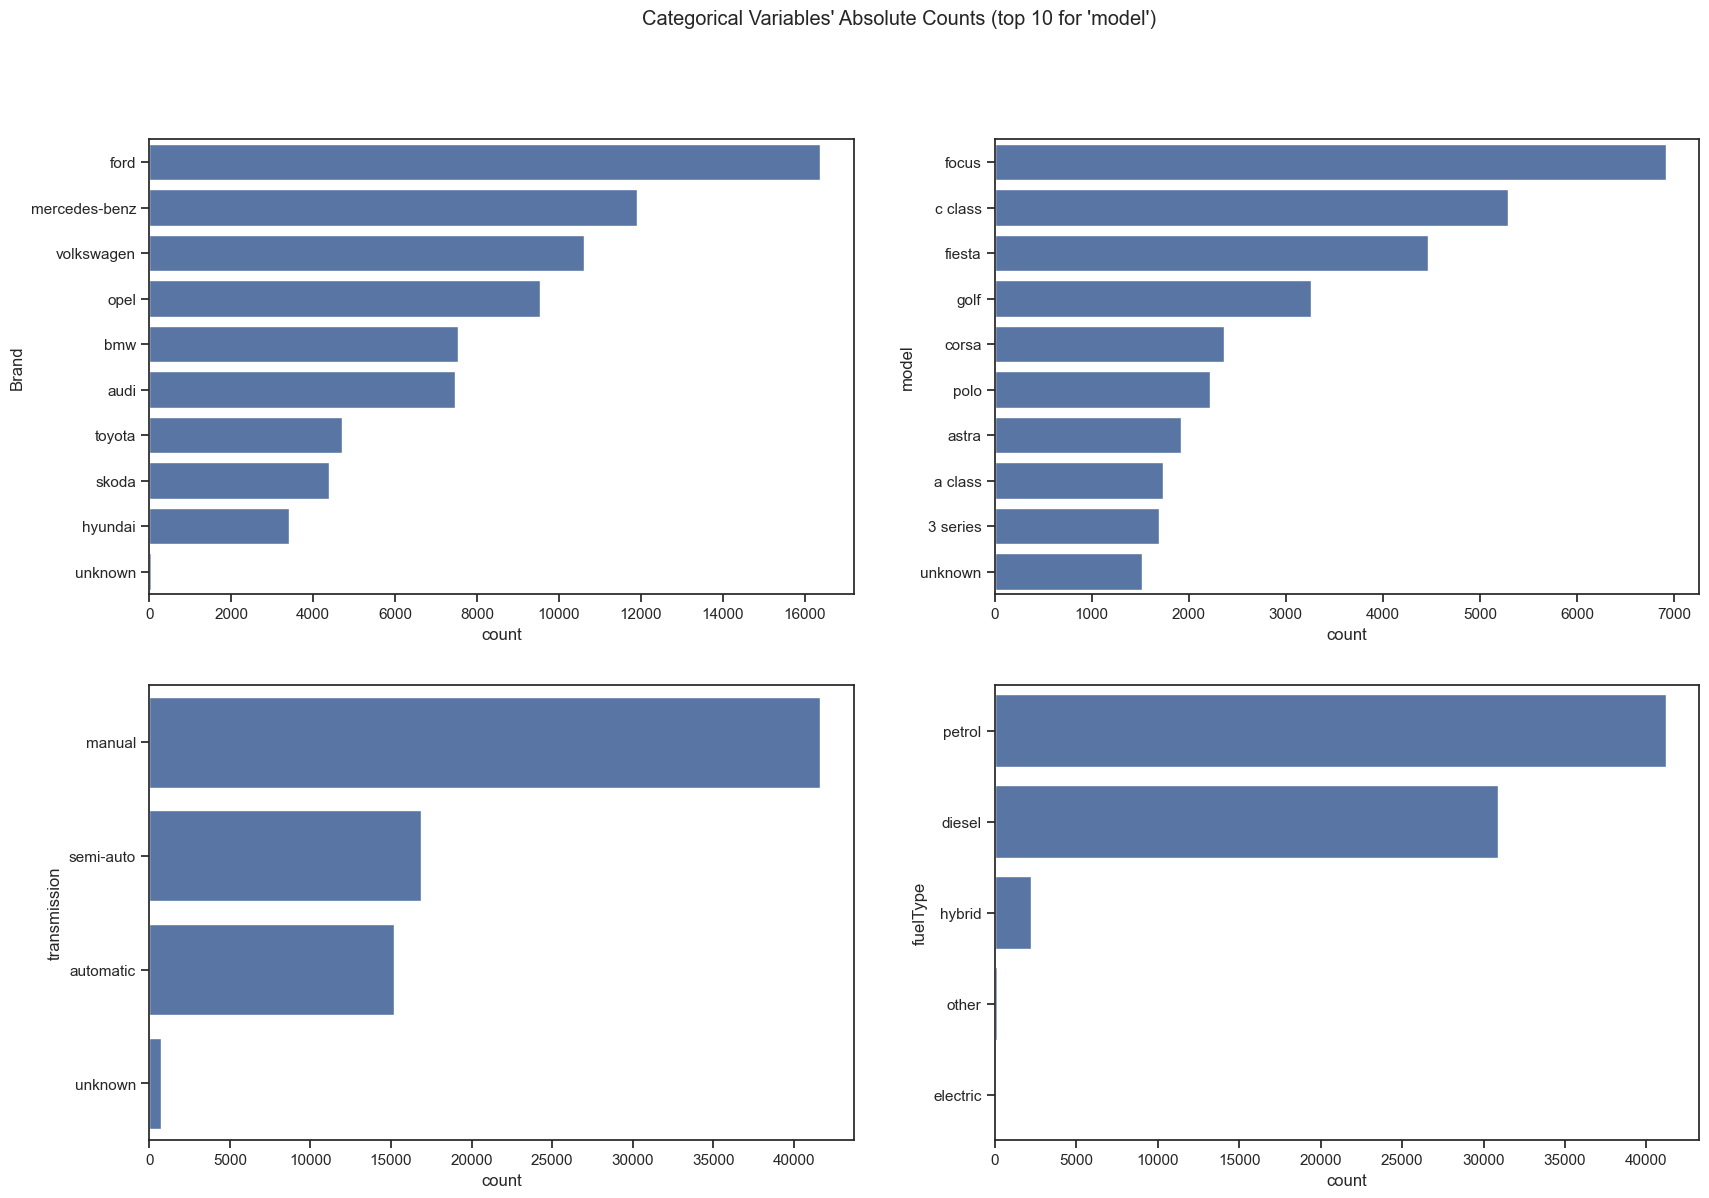

In [23]:
sns.set_style('ticks')

sp_rows = 2
sp_cols = 2

fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 13))

#only top 10 for model
for ax, feat in zip(axes.flatten(), non_metric_features):
    sns.countplot(y=feat, data=train, ax=ax, order=train[feat].value_counts().index[:10])

# Layout
# Add a centered title to the figure:
title = "Categorical Variables' Absolute Counts (top 10 for 'model')"

plt.suptitle(title)
plt.show()

`Brand` - Very skewed. Ford is clearly #1, followed by Mercedes-Benz, Volkswagen and Opel, then BMW and Audi.<br> 
<br>
`model` - Top models are mostly compact hatchbacks (Focus, Fiesta, Golf, Corsa, Polo, Astra), with C Class / A Class / 3 Series bringing a premium segment into the mix.<br>
<br>
`tranmission` - Manual dominates, with semi-auto and automatic far behind. We are expecting that transmission will correlate with price (auto/semi-auto typically pricier).<br>
<br>
`fuelType` - Petrol > Diesel >> Hybrid >>> Electric. There are almost no electric and 'other' cars, we definitely need to check those.

In data cleaning and preprecessing we will fill the 'unknown' classes and missing values.<br>
For Brand and model we will use a RandomForrestClassifier to re-assign the unknown observations.<br>
For transmission we will use mode by model, to re-assign the unknown observations and fill missing values.<br>
For fuelType we will fill the missing values with the mode by model.<br>
For fuelType we will also check the elctric and 'other' classes.

**Numerical Histograms and Boxplots**

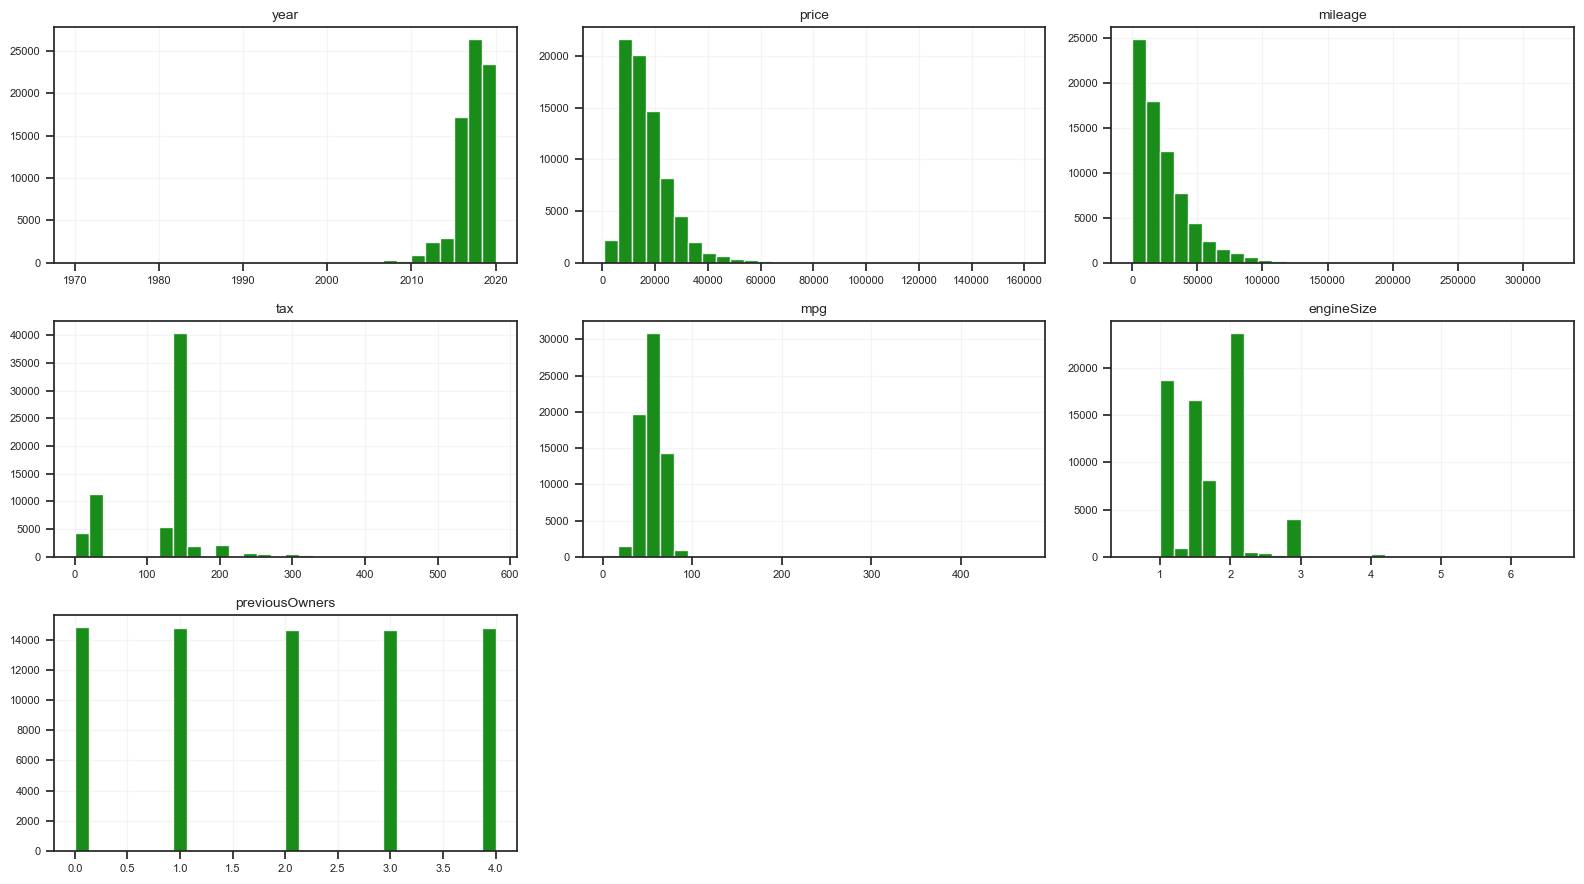

In [24]:
num = train.select_dtypes(include='number')
cols = num.columns.tolist()

exclude = {'carID', 'paintQuality%', 'hasDamage'}
cols = [c for c in num.columns if c not in exclude]

n = len(cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3*nrows))
axes = axes.flatten() if n > 1 else [axes]

for ax, col in zip(axes, cols):
    ax.hist(num[col].dropna(), bins=30, color='green', edgecolor='white', alpha=0.9)
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.2)

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

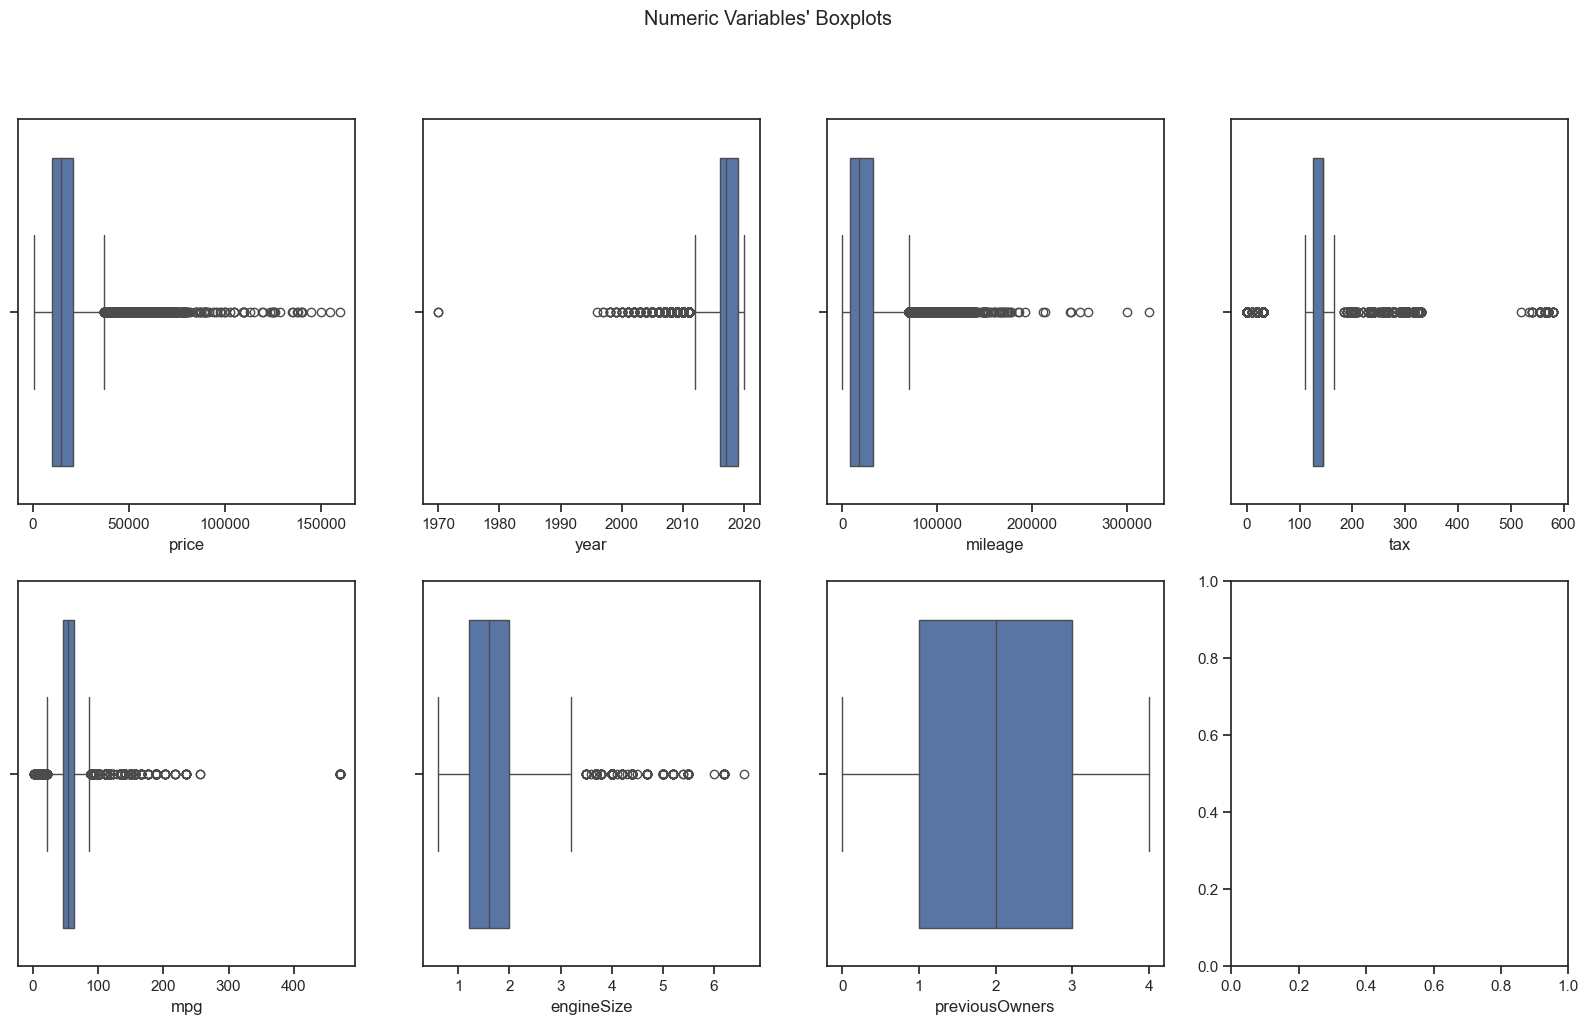

In [25]:
# Plot ALL Numeric Variables' Boxplots in one figure

sns.set_style('ticks')

sp_rows = 2
sp_cols = 4

# Prepare figure. Create individual axes where each histogram will be placed
fig, axes = plt.subplots(sp_rows, 
                         sp_cols, 
                         figsize=(20, 11))

# Plot data
# Iterate across axes objects and associate each histogram
for ax, feat in zip(axes.flatten(), metric_features): 
    sns.boxplot(x=train[feat], ax=ax)
    
# Layout
# Add a centered title to the figure:
title = "Numeric Variables' Boxplots"

plt.suptitle(title)
plt.show()

`year` - Skewed, massively concentrated between 2014 and 2020. We will create avariable "*carAge*" = ref_year - year because age is easier to model. Narrow span means age will be a strong driver. Near 1970 outlier.<br>
<br>
`price`(**Target variable**) - Heavy right-skew with a long tail. In the future try to apply log<br>
<br>
`mileage` - Also right-skewed (long tail). In the future try to apply log1p(mileage).<br>
<br>
`mpg` - Tight around ~40–70 mpg with few extremes.<br>
<br>
`engineSize` - Most of the sizes are between 1-3<br>
<br>
`previousOwners` - Looks nearly uniform, check for correlation with price (probably more owners less the price)<br>
<br>
`tax` - Looks skewed and highly concentrated between 100-200, there's also very sparse groups of outliers, try to use tax in bins<br>

We will give a more in-depth check of outliers and deal with them in a section called "Dealing with Outliers" in "Feature Engineering".

### 2.2.2 Bivariate Analysis

#### 2.2.2.1 Numerical - Numerical

**Corelations Heatmap**<br>
<br>
We use Spearman’s ρ because several variables are skewed/heavy-tailed. Spearman is rank-based, more robust to outliers, captures monotonic (not necessarily linear) relations, and is invariant to monotonic transforms

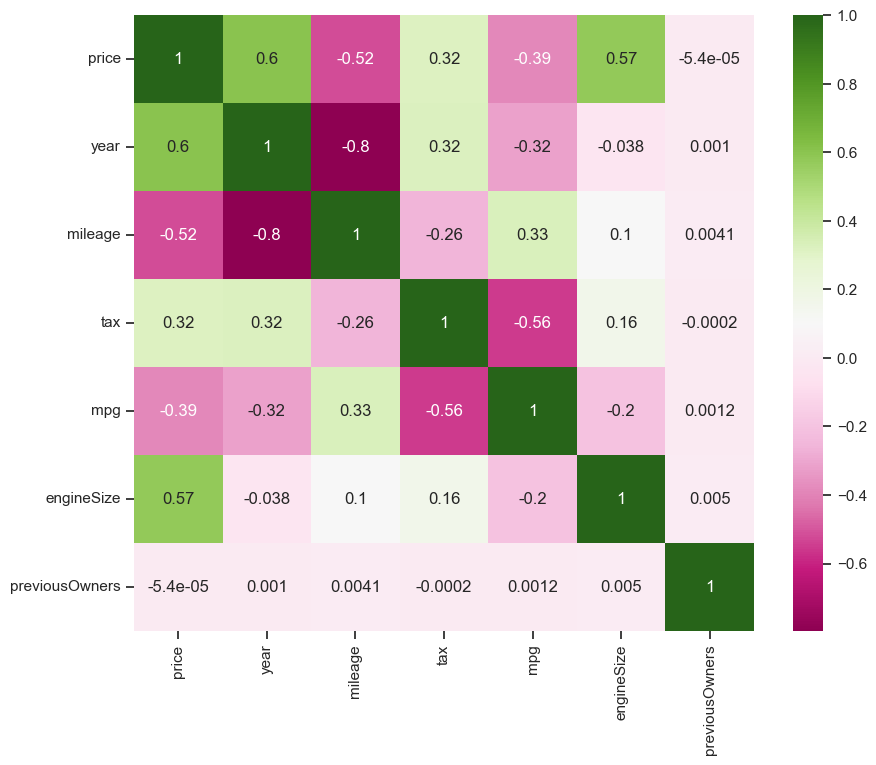

In [26]:
fig = plt.figure(figsize=(10, 8))
threshold = 0.3

corr = train[metric_features].corr(method="spearman")

annot = corr.round(2).astype(str)
annot_masked = annot.where(corr.abs() >= threshold, '') 

sns.heatmap(data=corr,annot= True, cmap = 'PiYG')

plt.show()

- Strongest rank links with price: year (ρ≈+0.60), engineSize (ρ≈+0.57), and lower mileage (ρ≈−0.52) → newer, bigger-engine, lower-mileage cars rank higher in price.<br>
<br>
- Tax/Efficiency signal: tax vs mpg (ρ≈−0.56).<br>
<br>
- High collinearity to manage: year vs mileage (ρ≈−0.79).<br>
<br>
- Near-zero signals: paintQuality% and previousOwners show ~0 correlation with price/others<br>


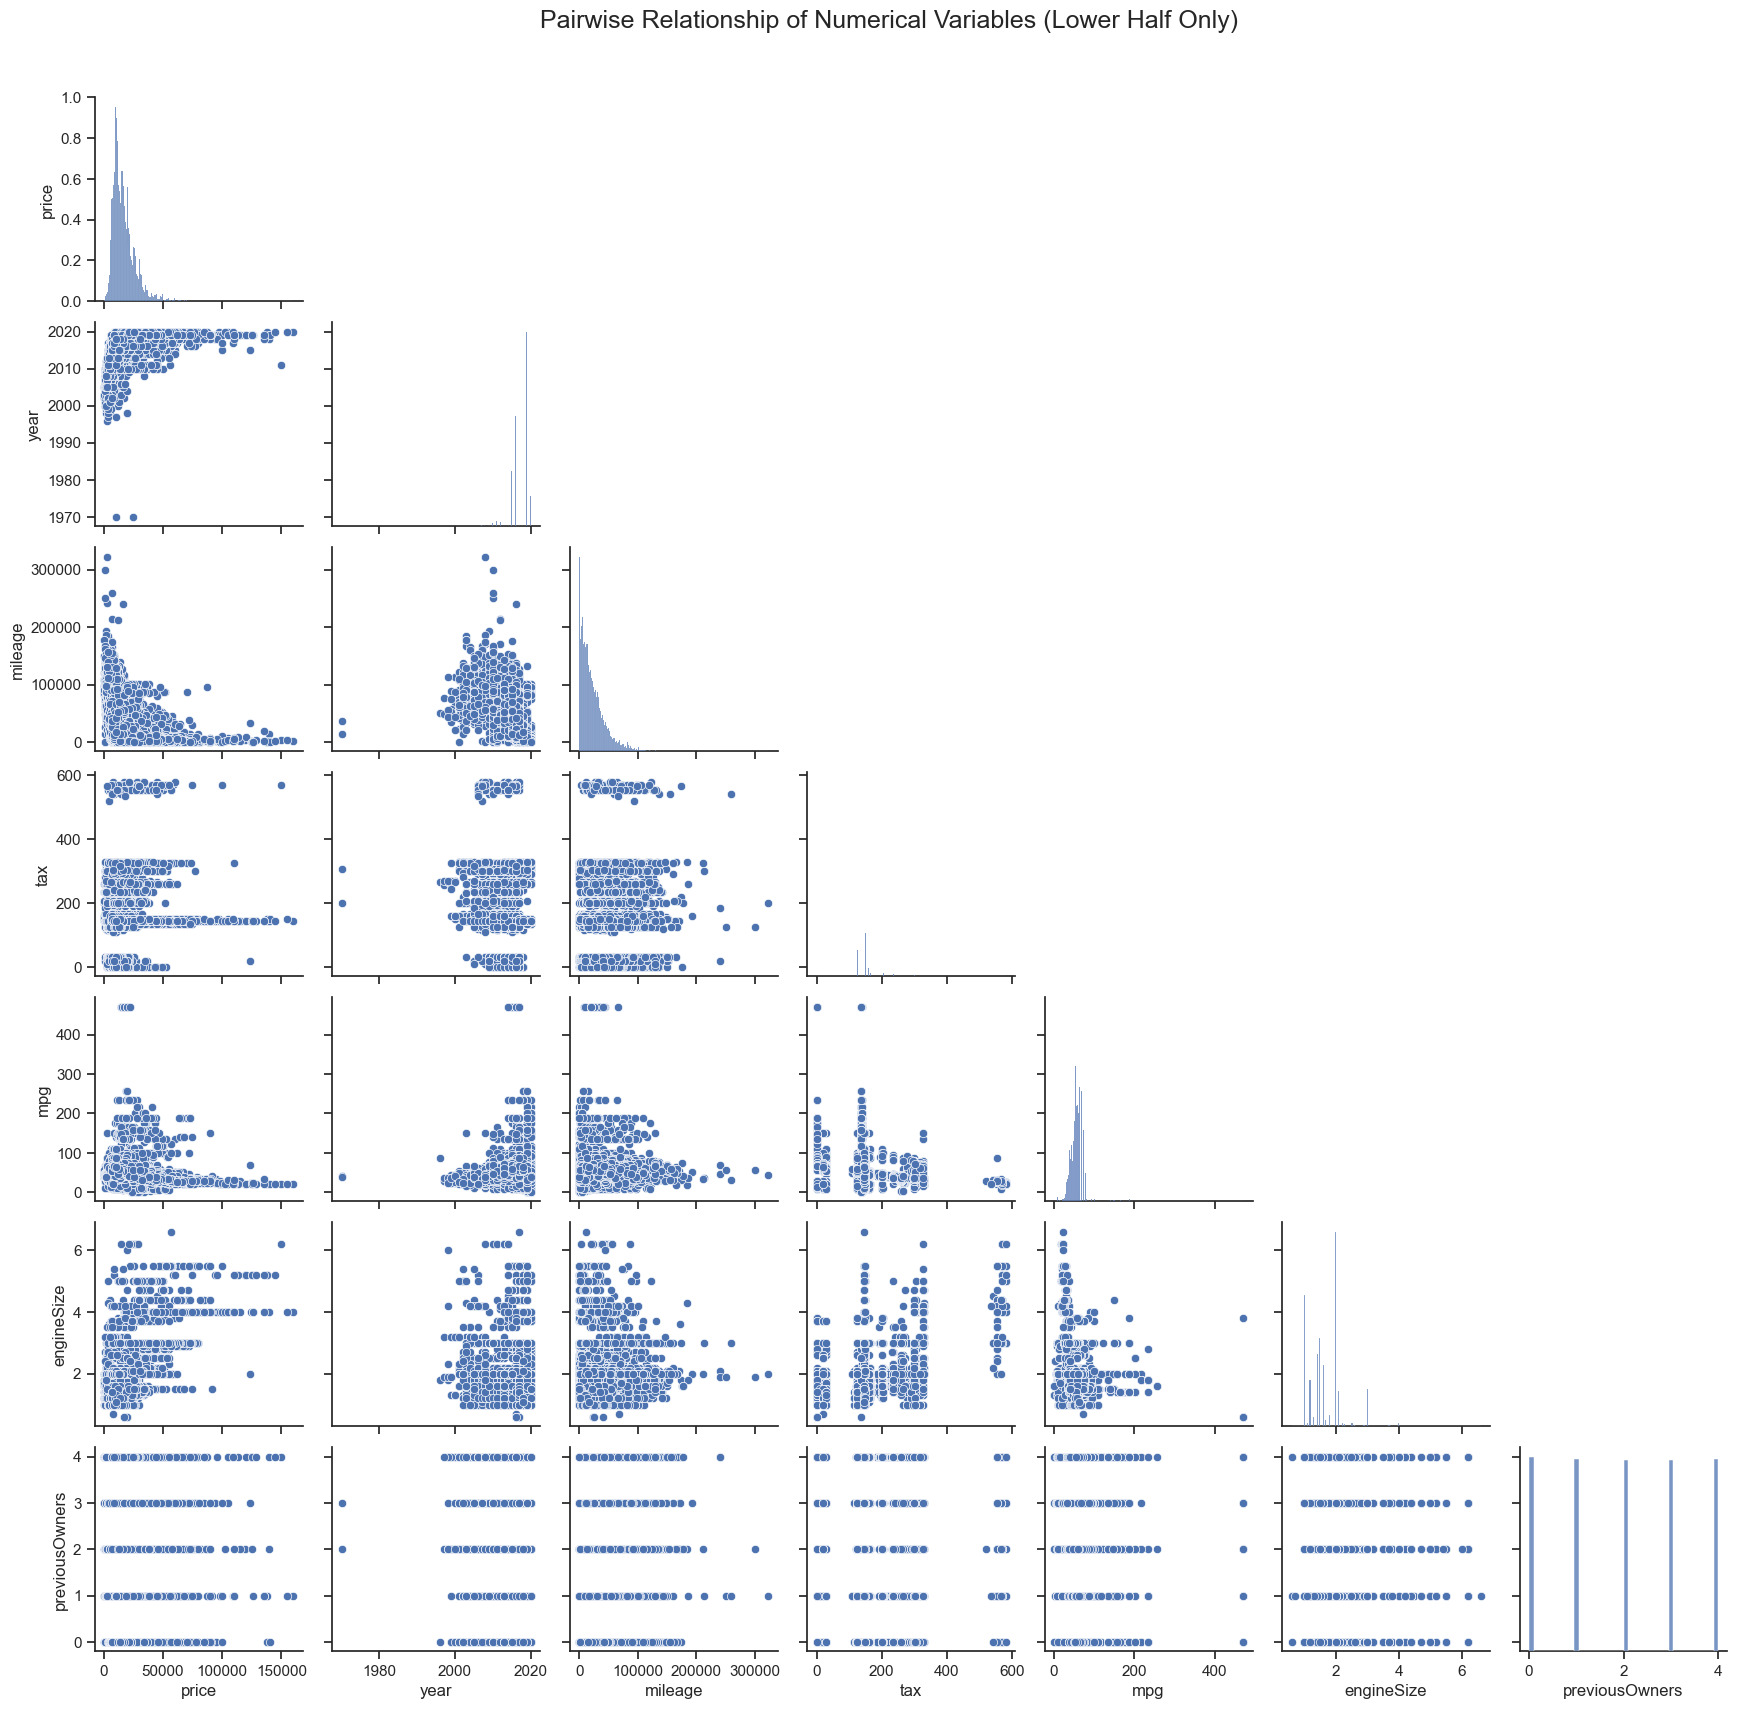

In [27]:
sns.set_style("ticks")

num_cols = len(metric_features)

g = sns.PairGrid(train[metric_features], diag_sharey=False)
g.map_lower(sns.scatterplot)
g.map_diag(sns.histplot, kde=False)

for i, j in zip(*np.triu_indices_from(g.axes, 1)):
    g.axes[i, j].set_visible(False)

plt.subplots_adjust(top=0.93)
g.fig.suptitle("Pairwise Relationship of Numerical Variables (Lower Half Only)", fontsize=18)

plt.show()

- newer cars can be more efficient (mpg-year)
- pricier cars are less efficient (mpg-price)
- when tax is above 400 engineSize is never below 2L, and for tax below 400 engineSize higher than 4L is not so common

#### 2.2.2.2 Categorical - Numerical

Here we check visualizations between any Categorical - Numerical relationship (besides model which have too many unique values).<br>
We use comparitive boxplots and barplots.

!! The analysis is after all of these visualizations !!

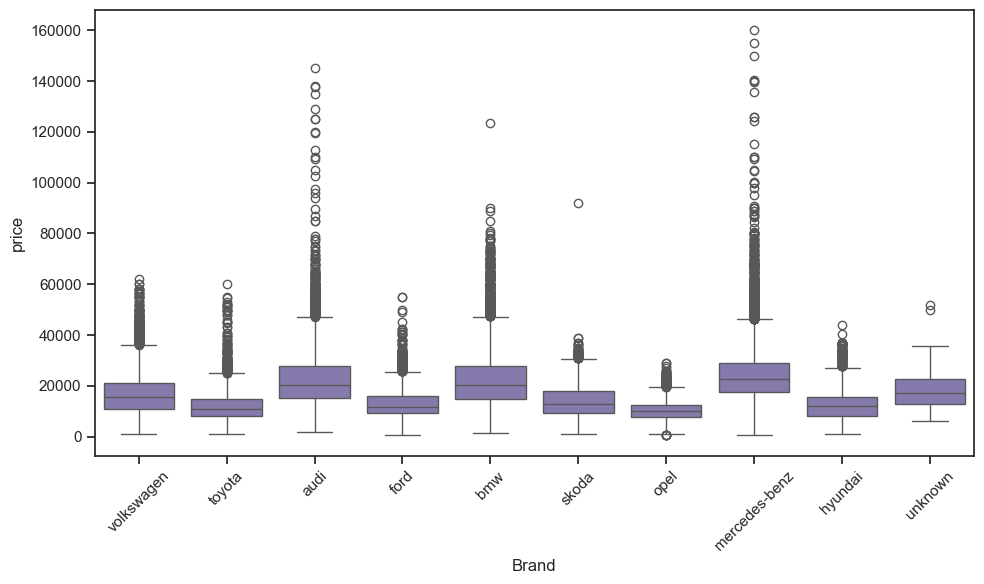

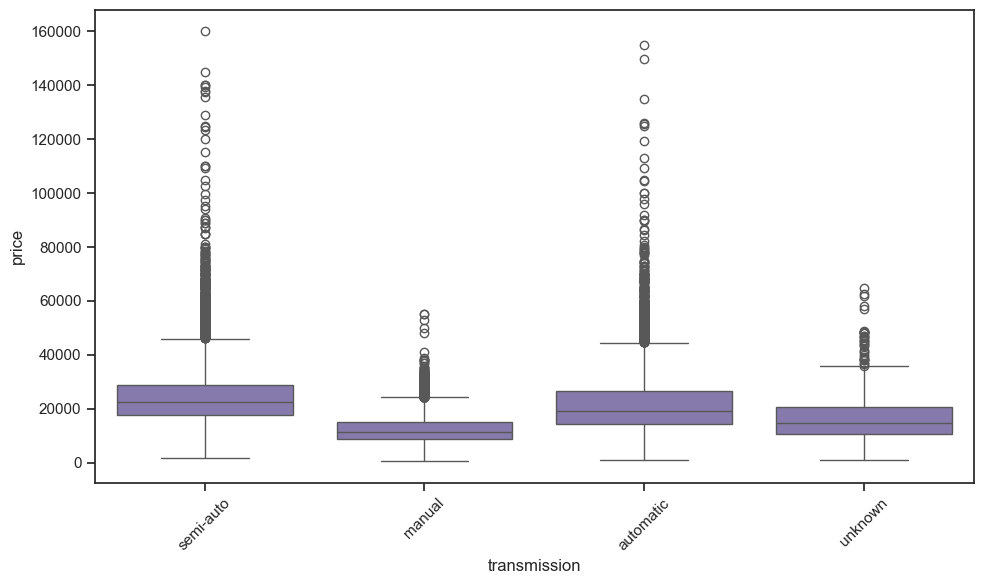

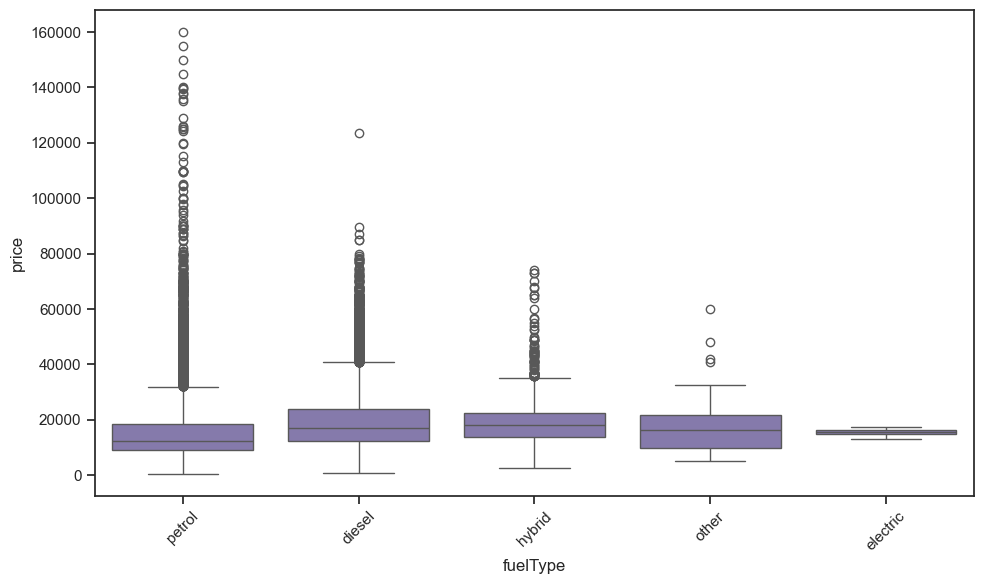

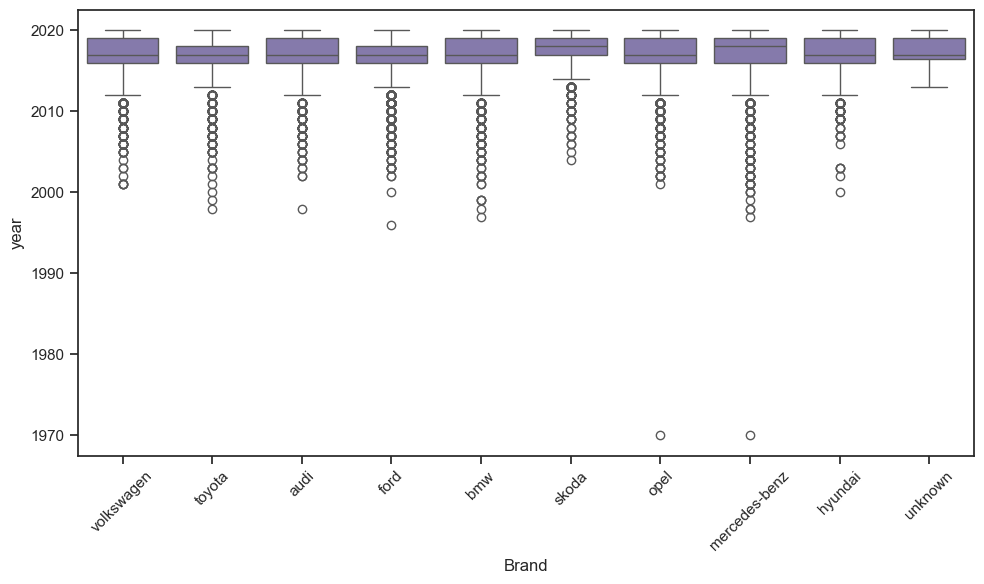

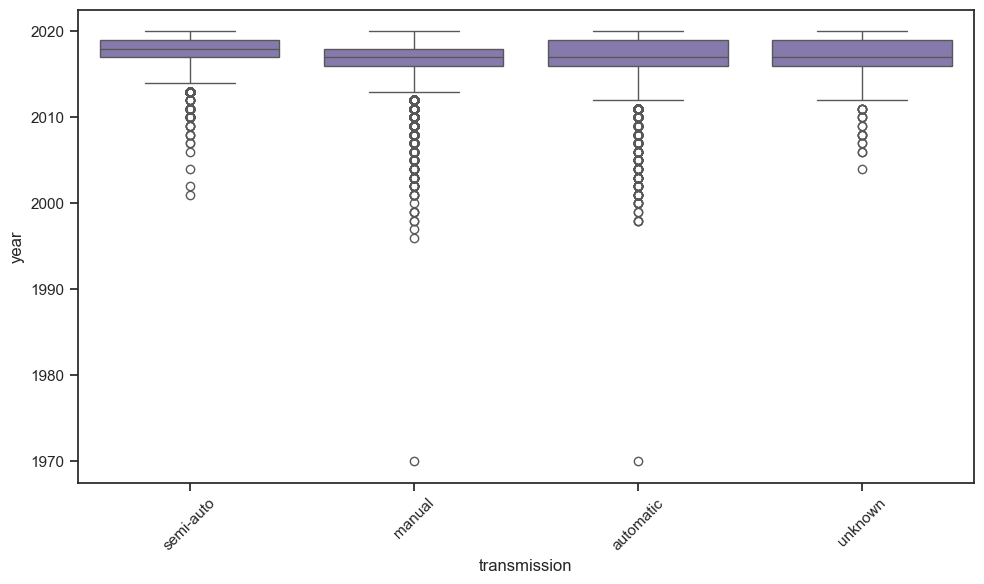

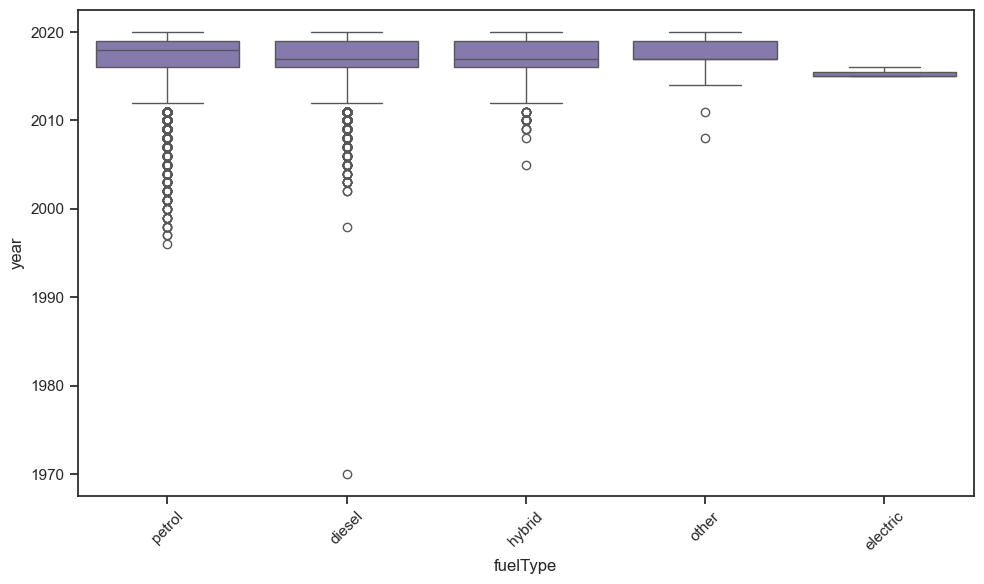

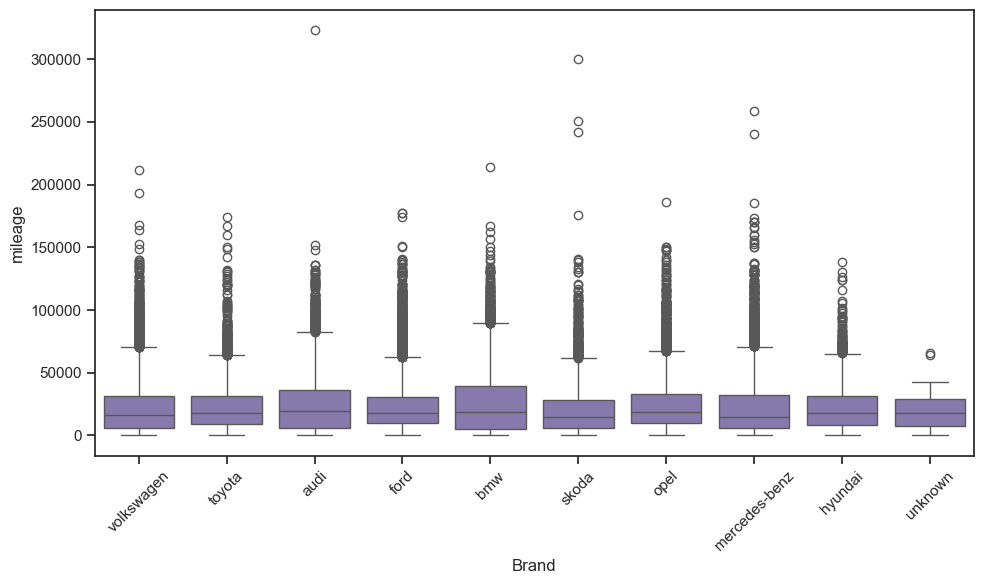

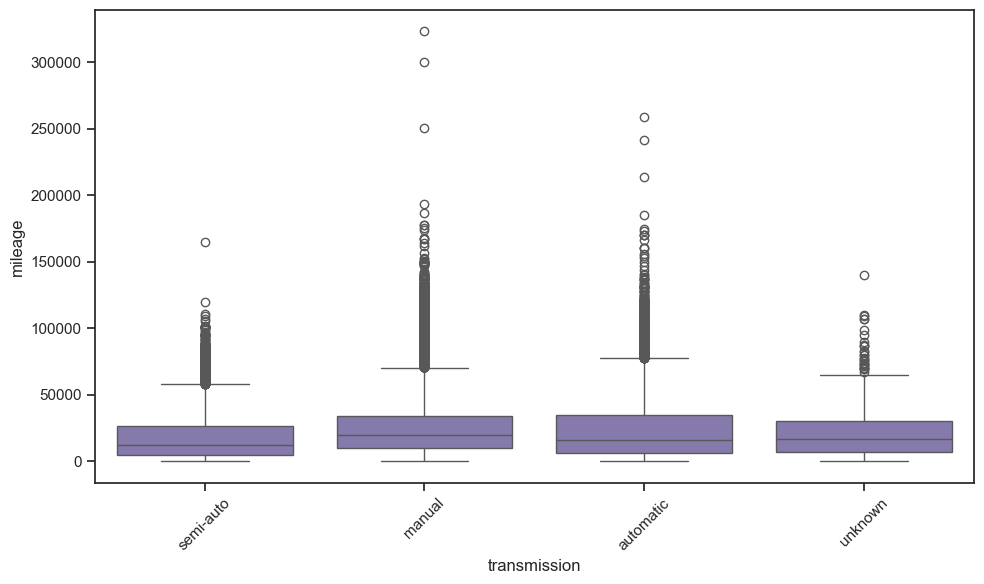

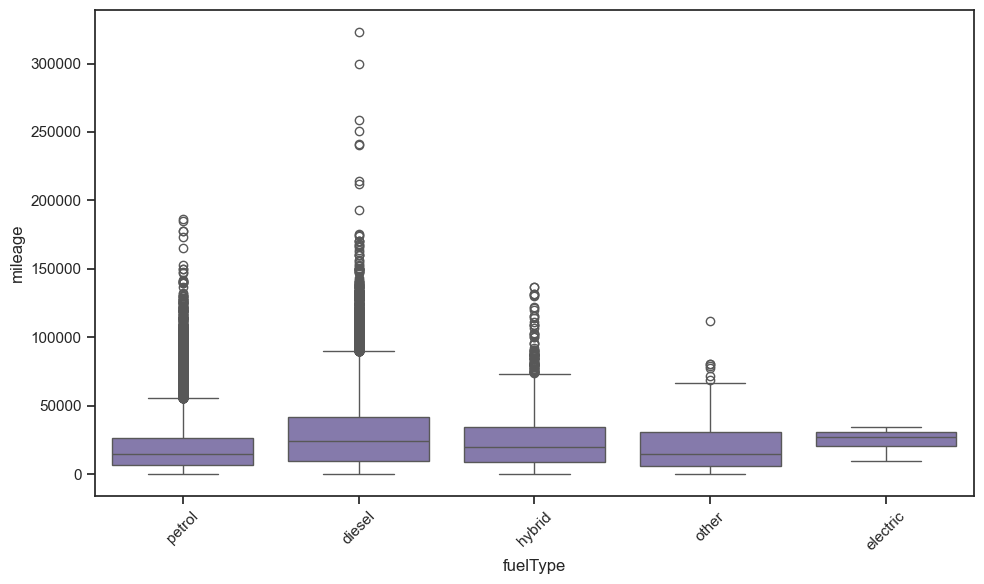

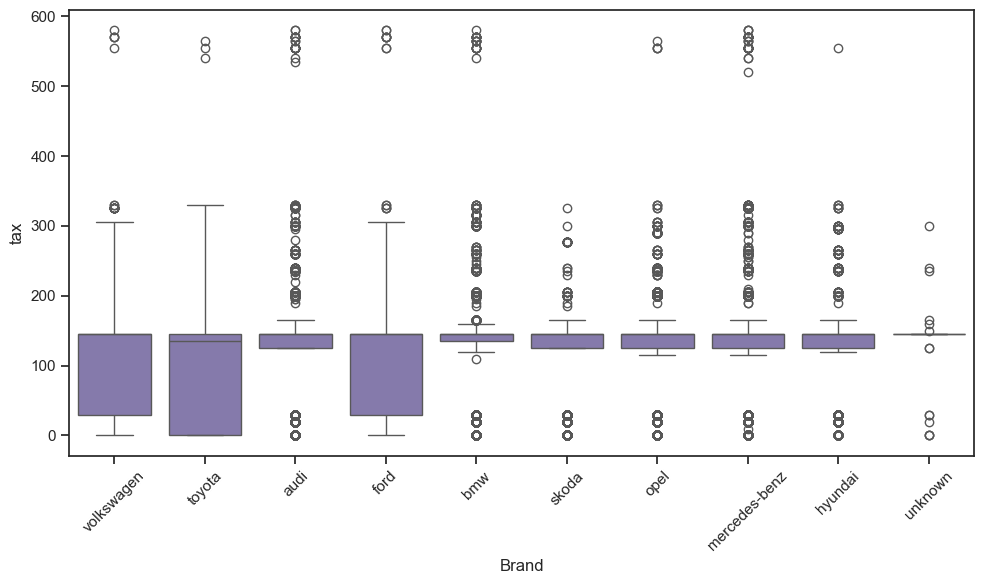

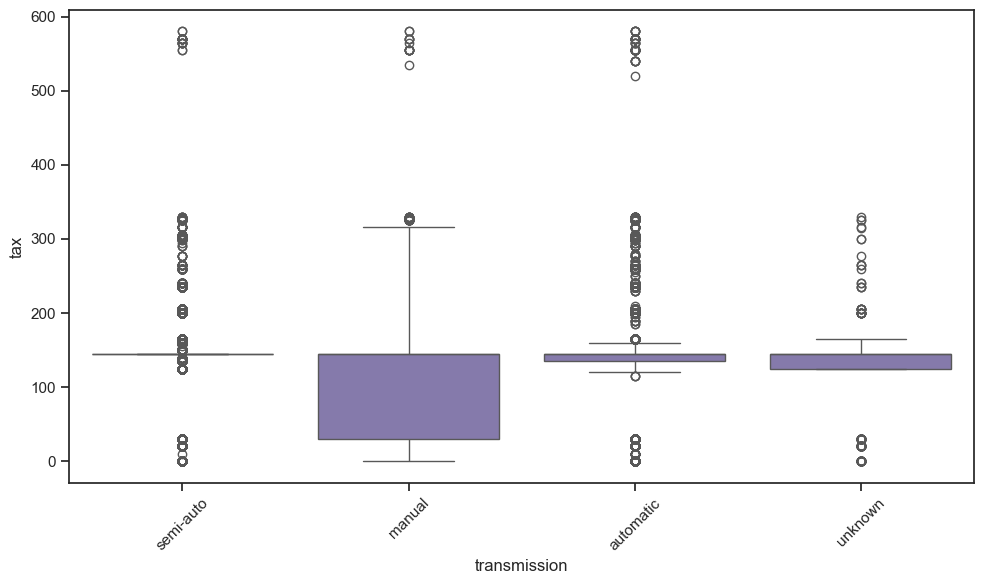

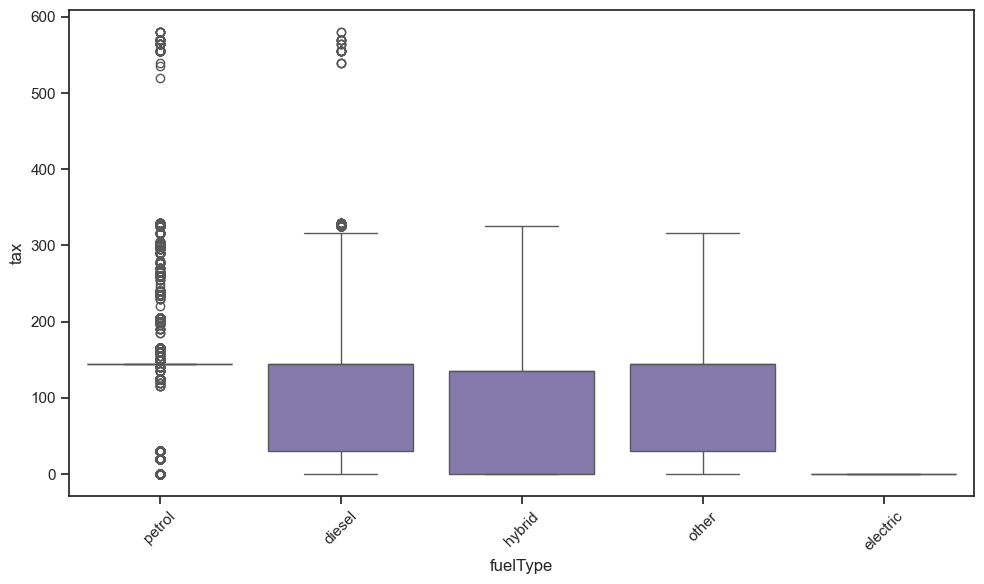

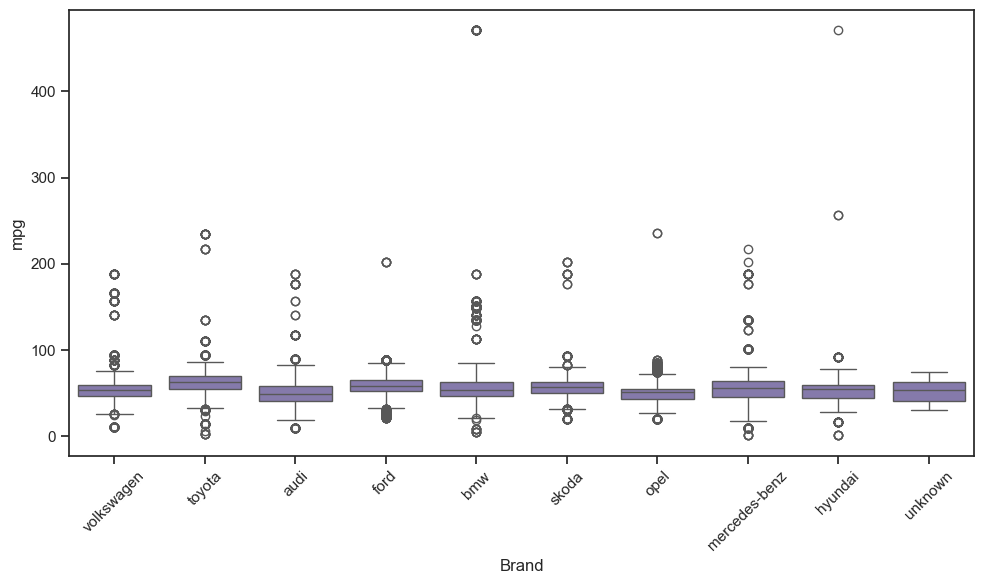

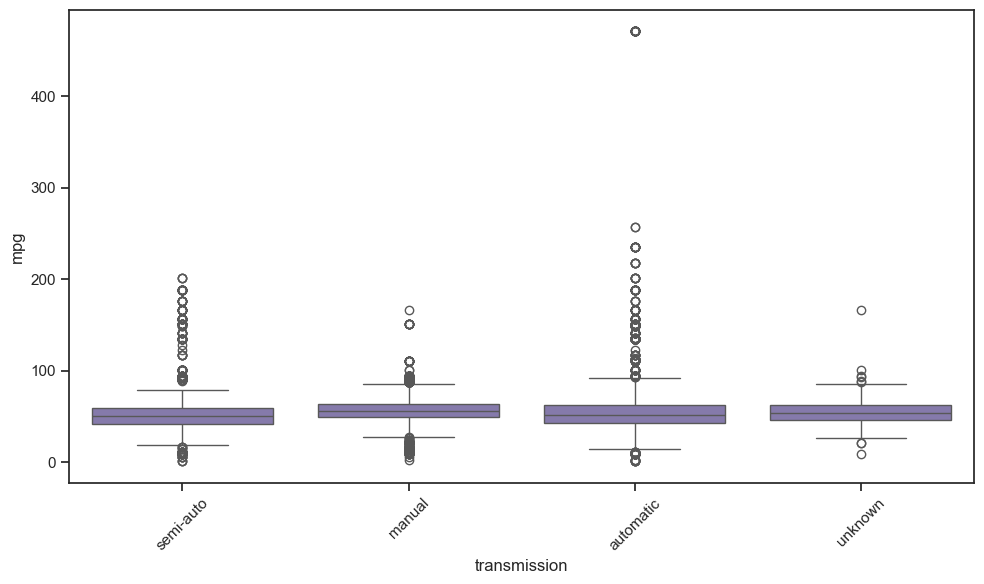

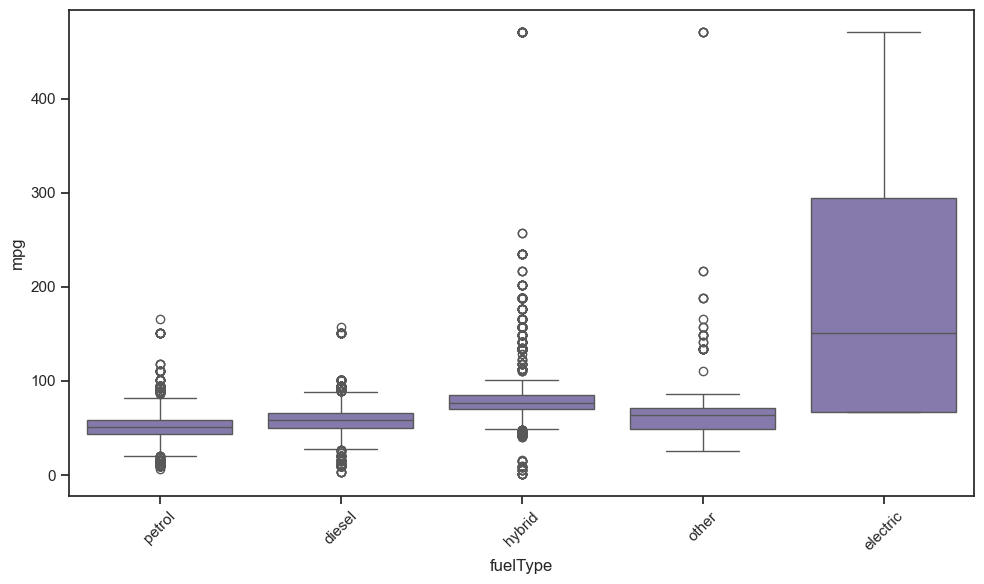

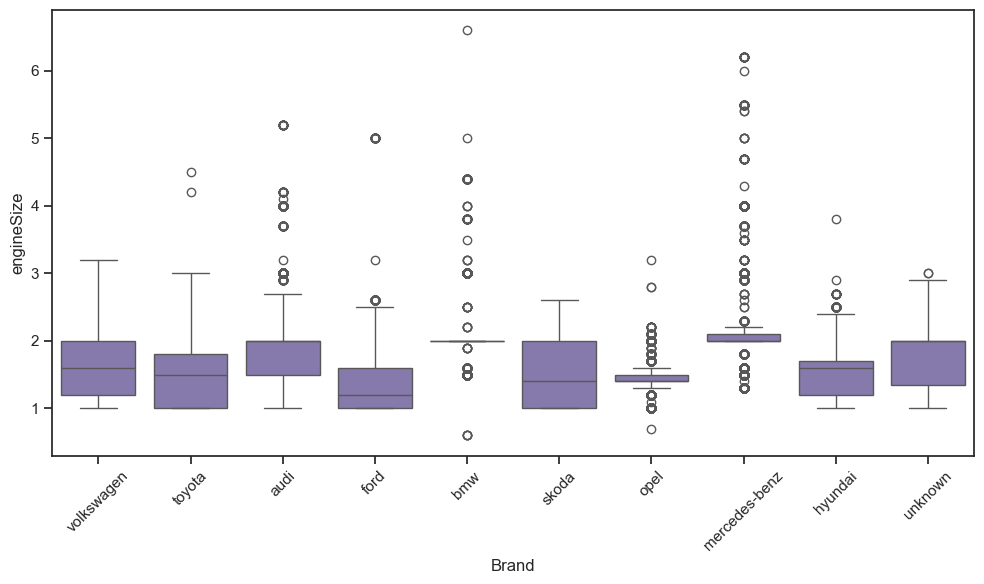

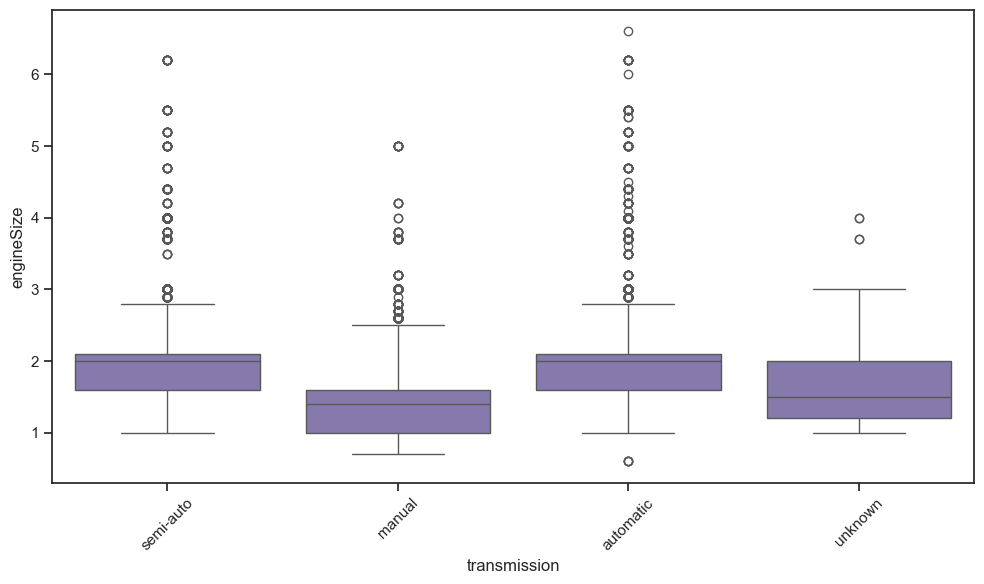

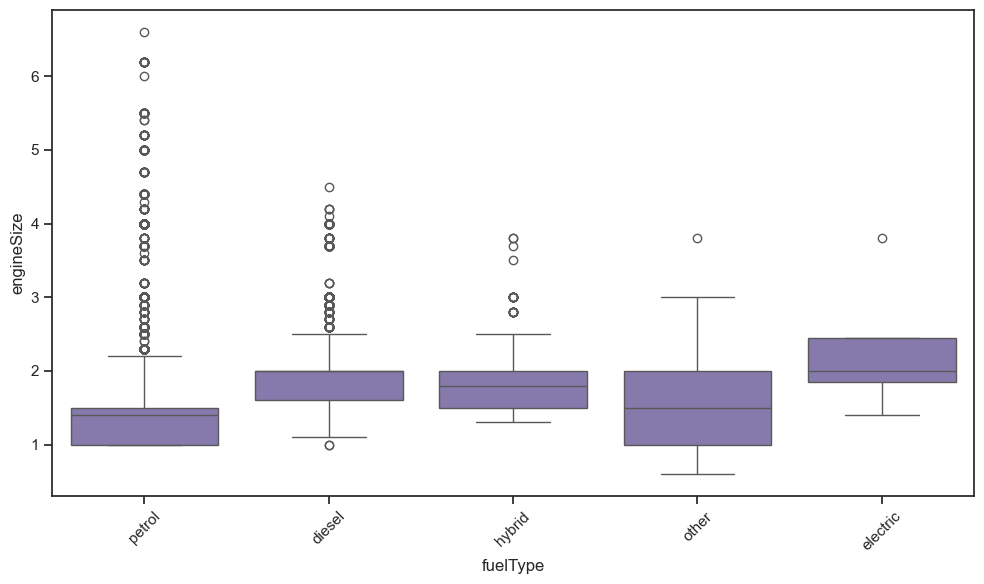

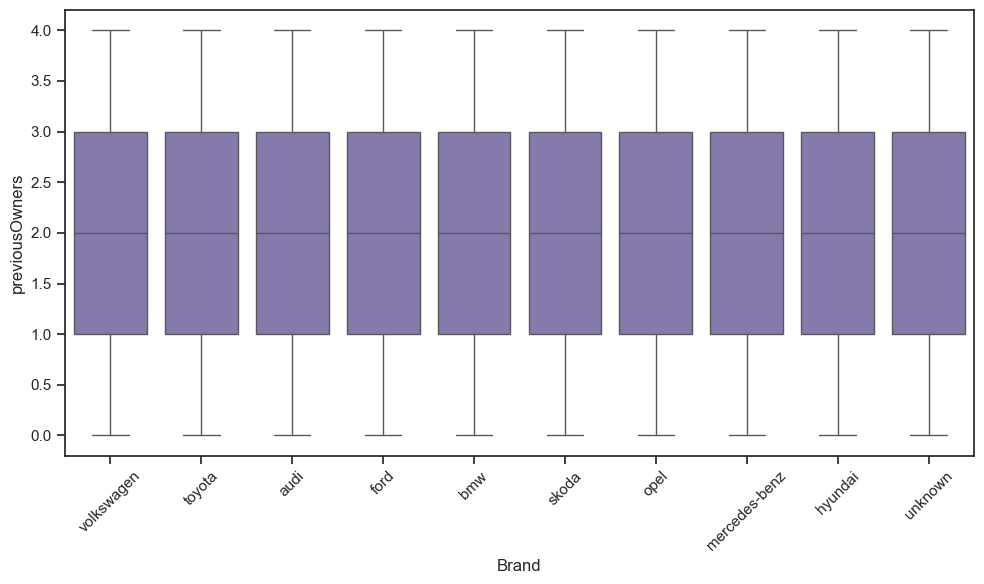

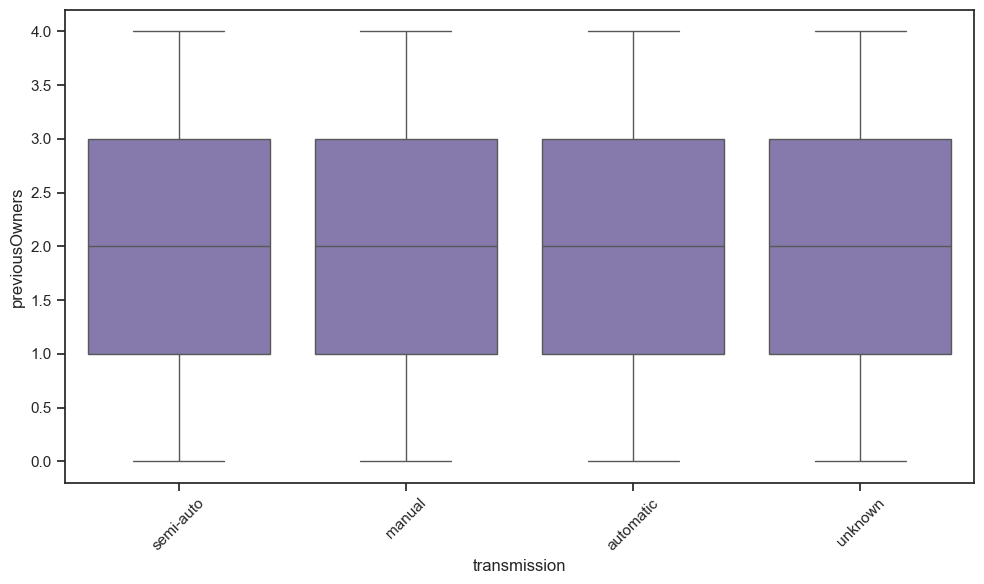

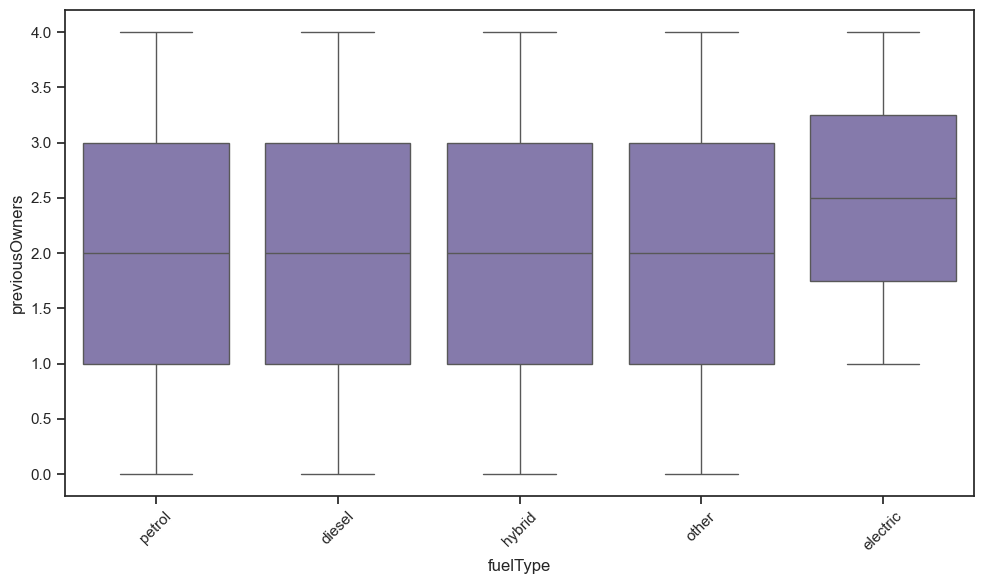

In [28]:
for column in metric_features:
    for x in [f for f in non_metric_features if f != 'model']:
        comparative_boxplot(train, x, column)


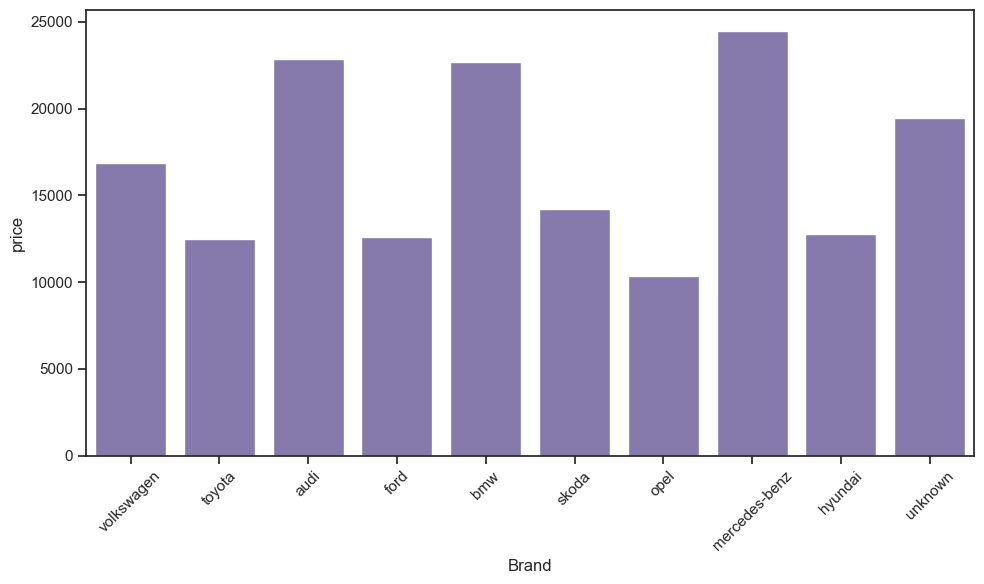

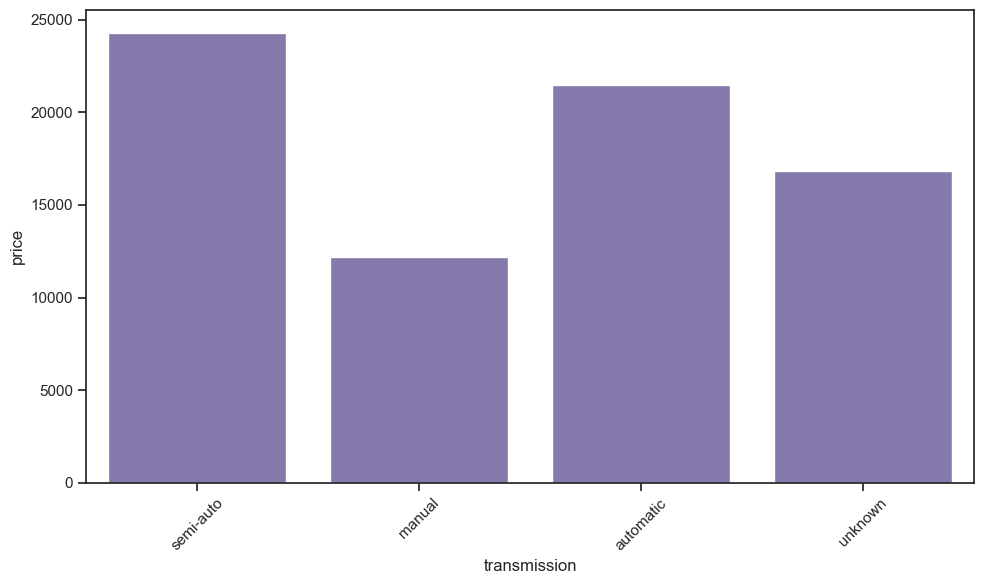

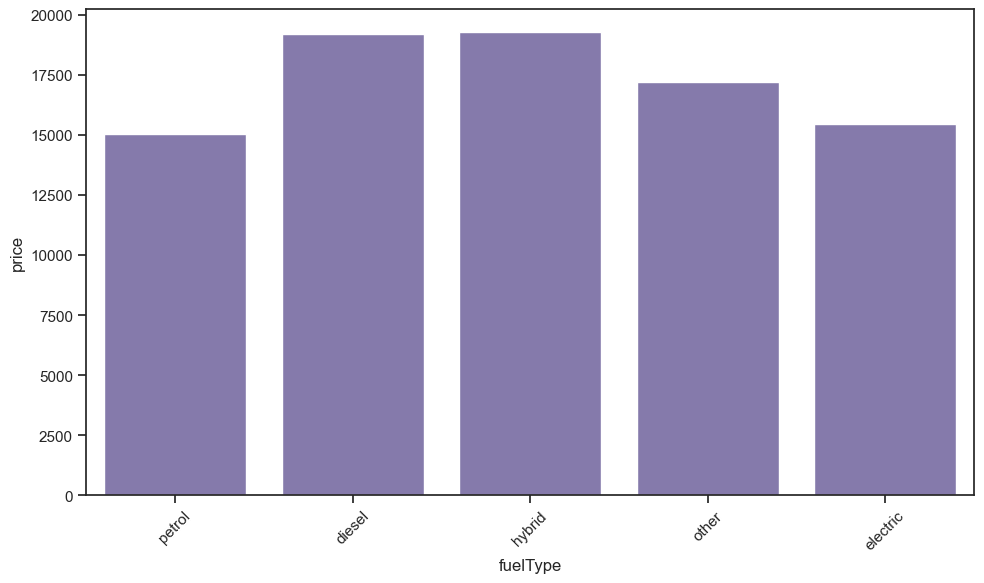

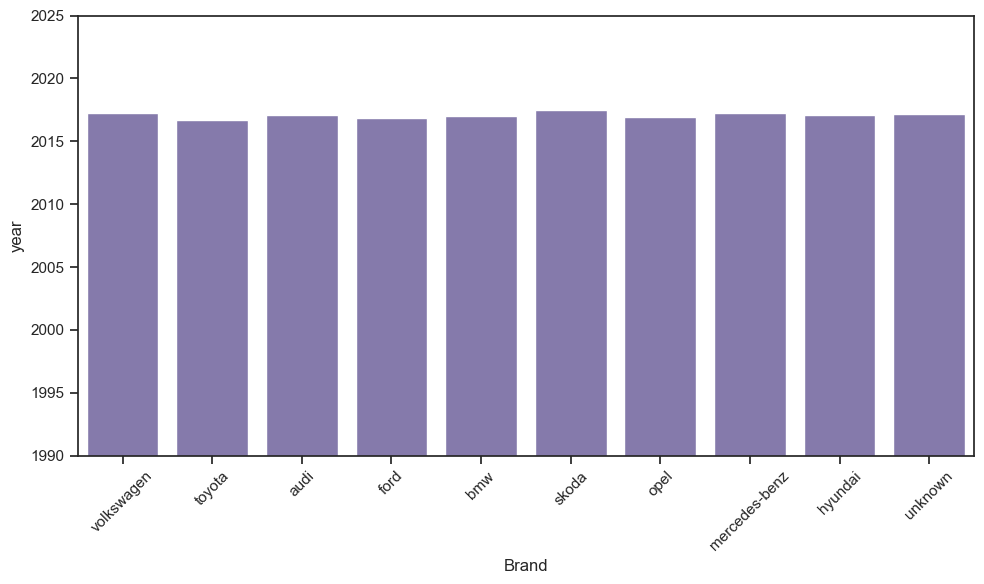

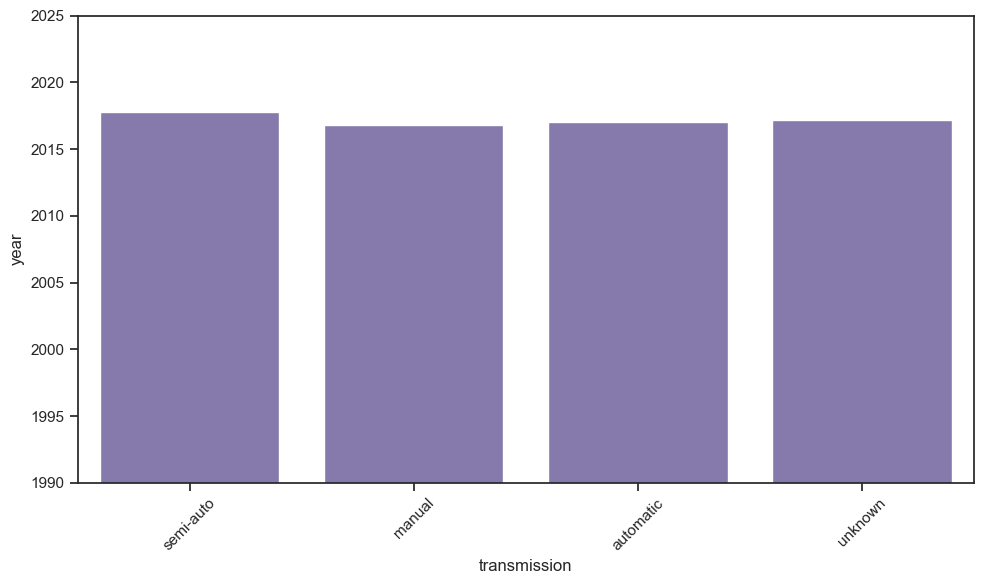

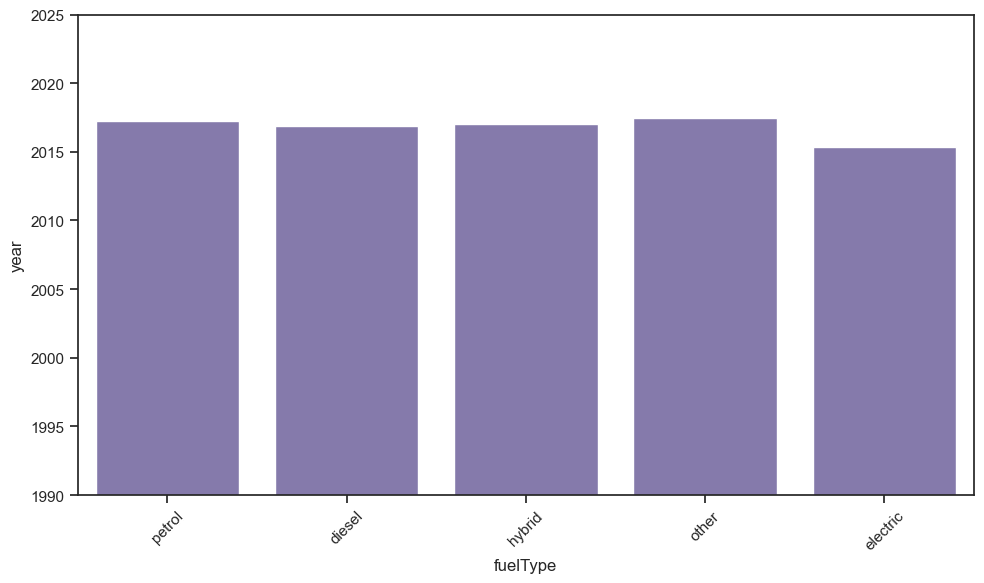

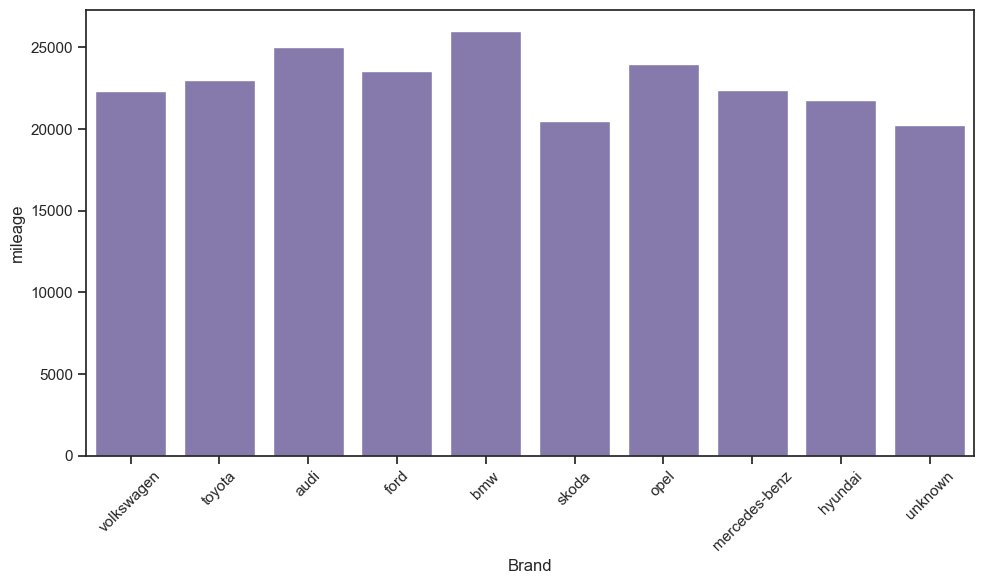

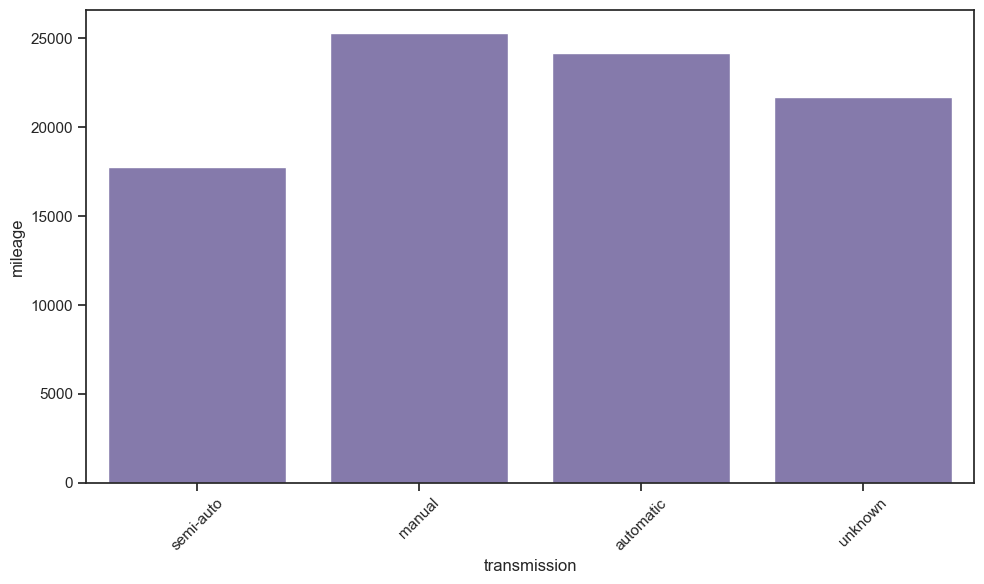

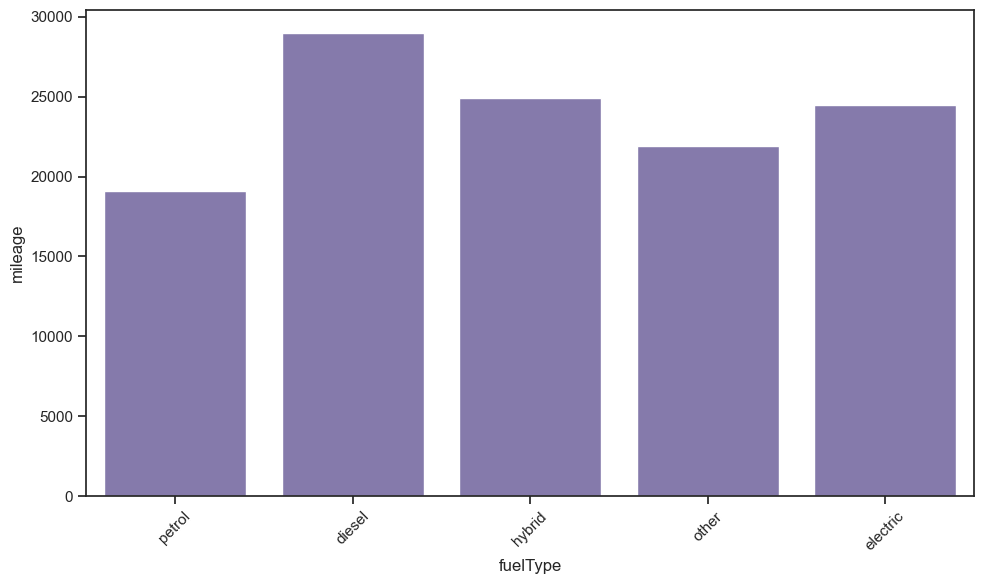

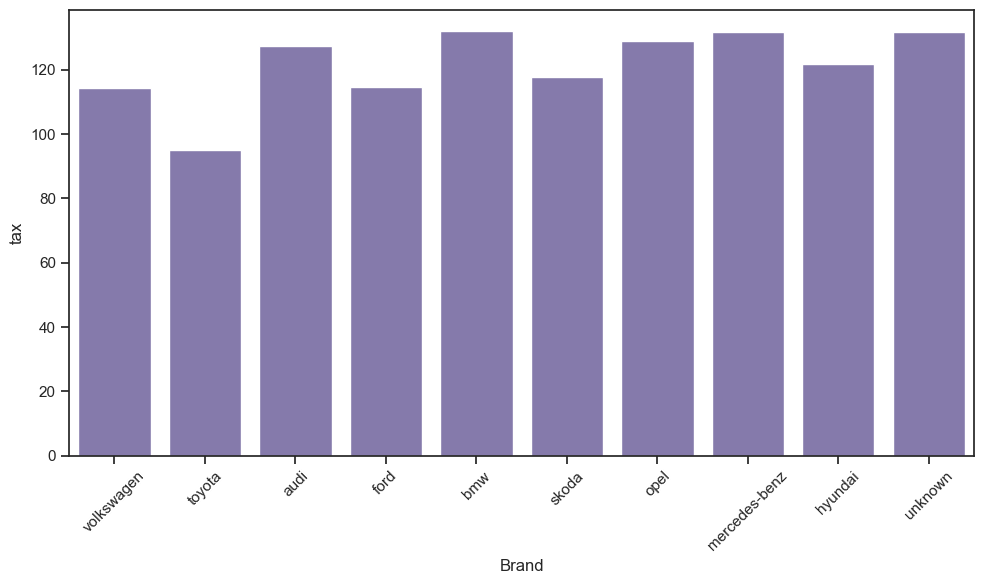

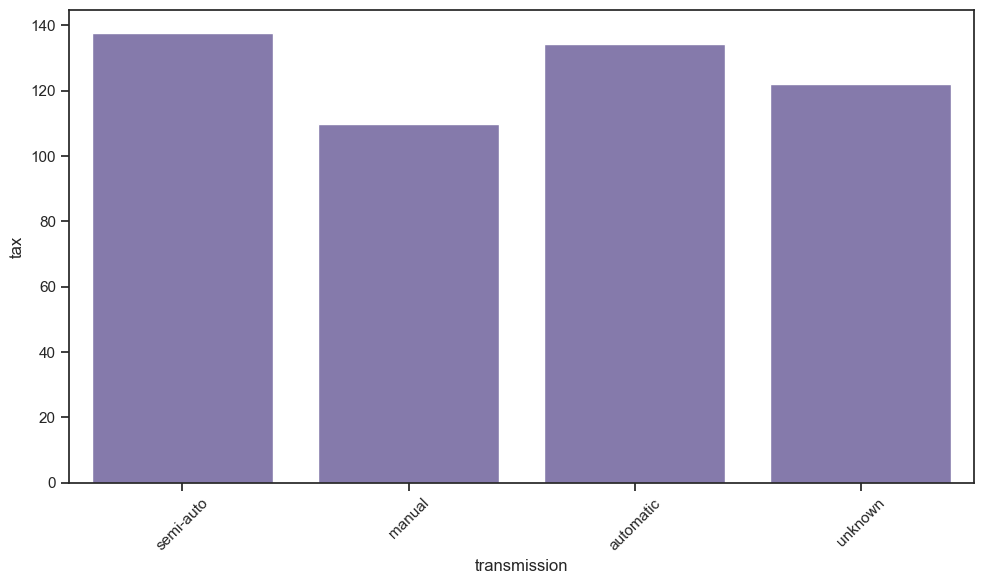

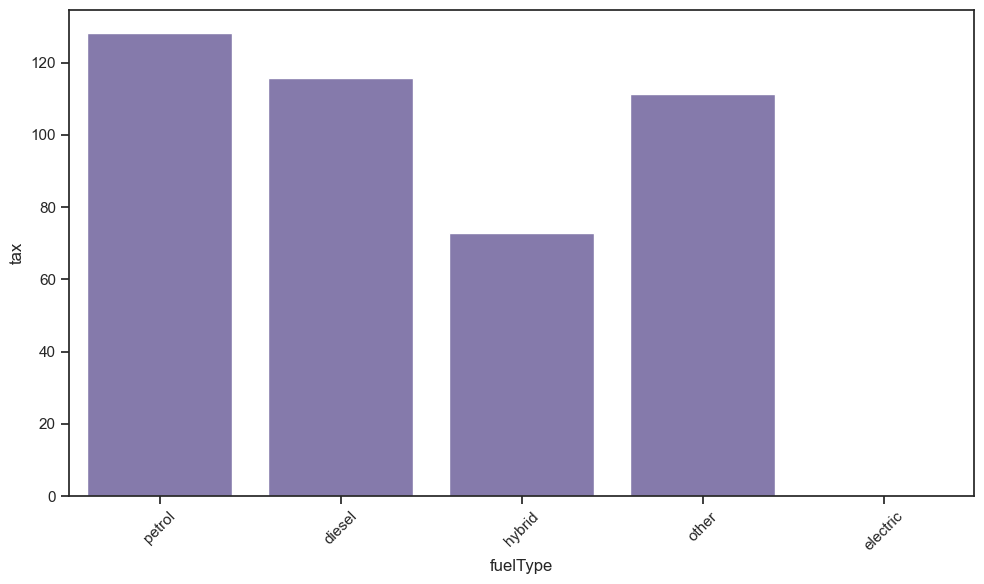

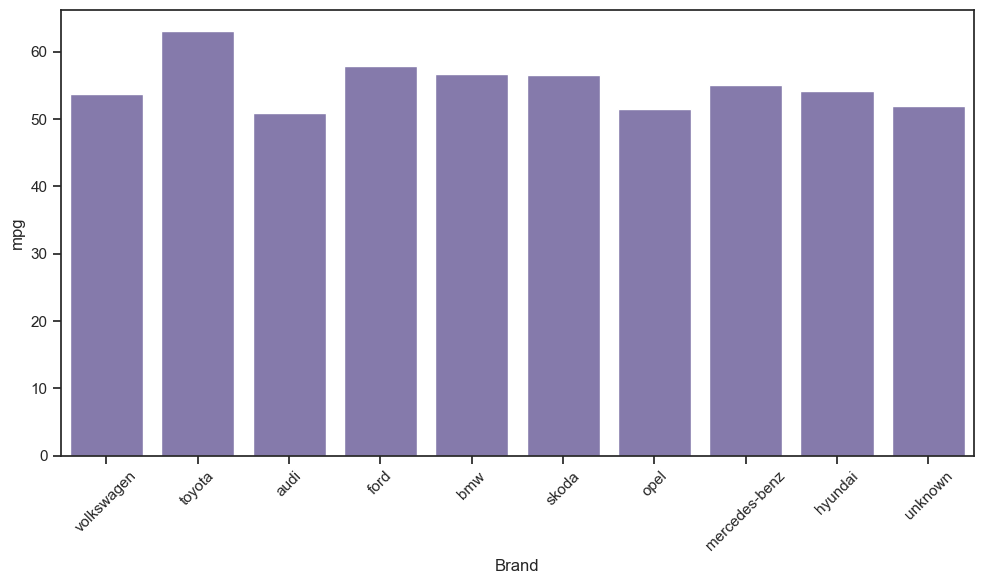

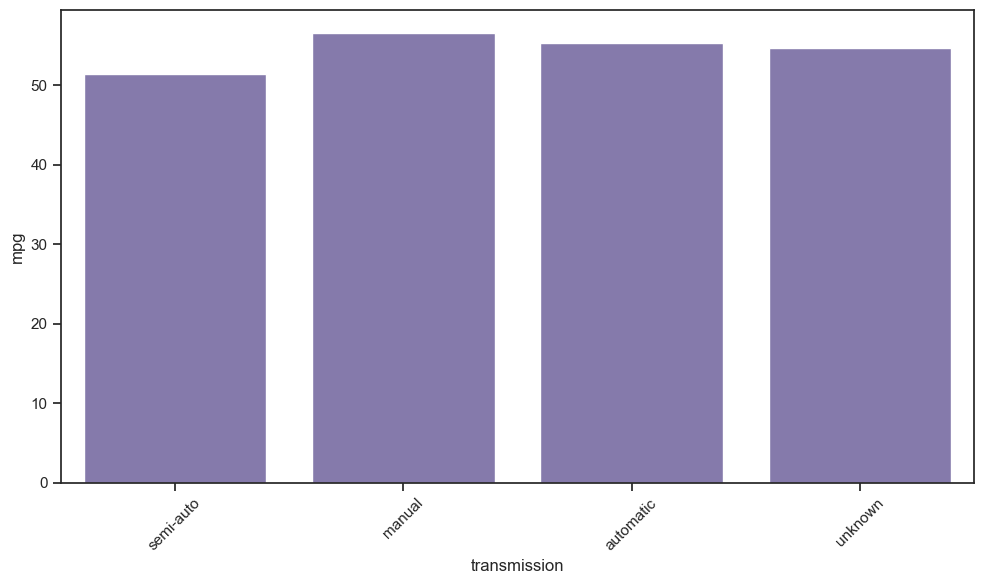

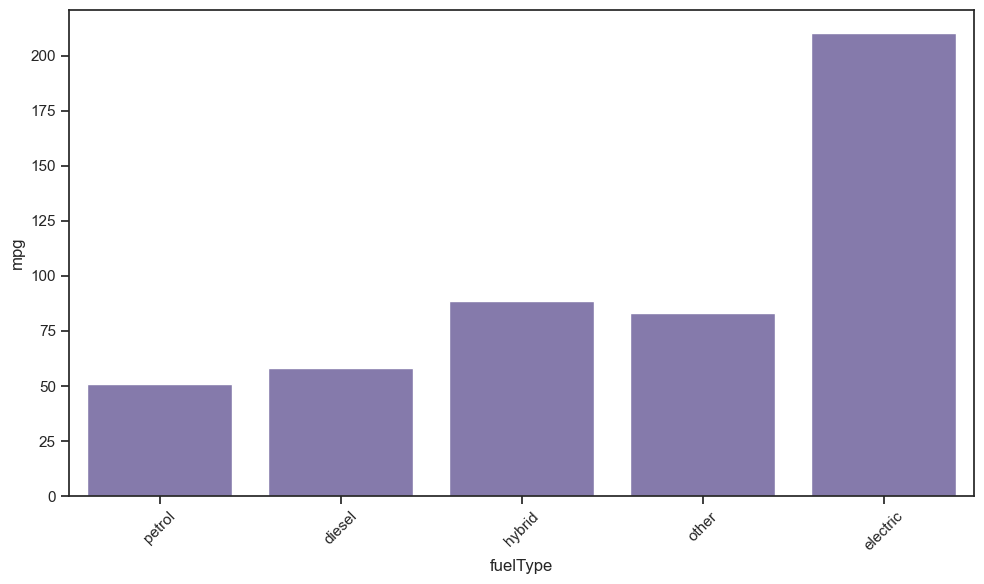

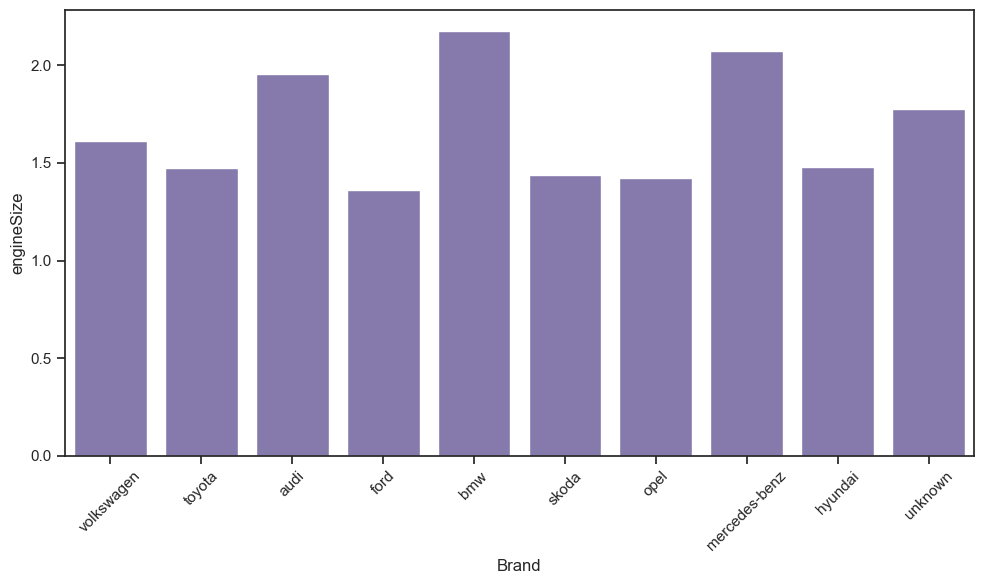

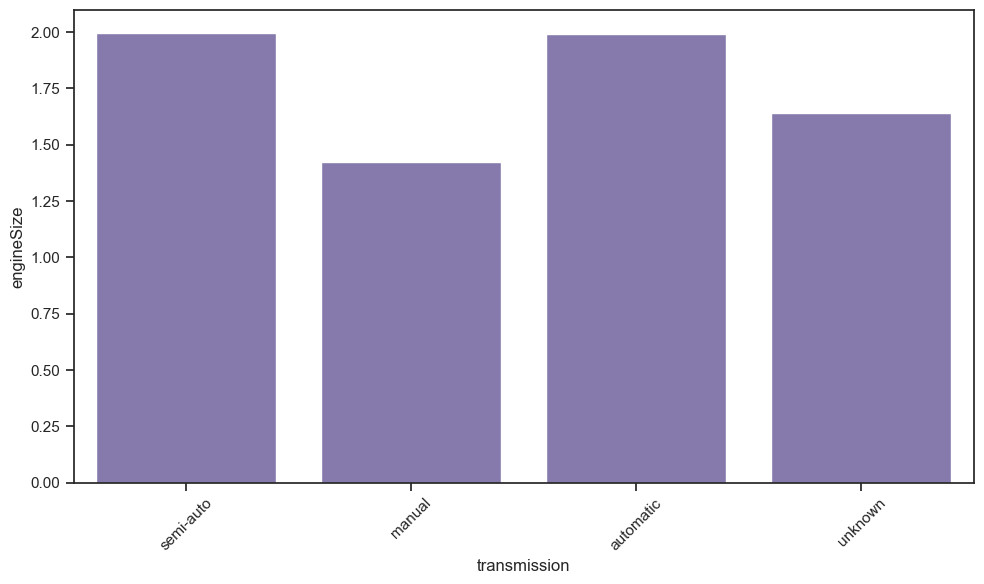

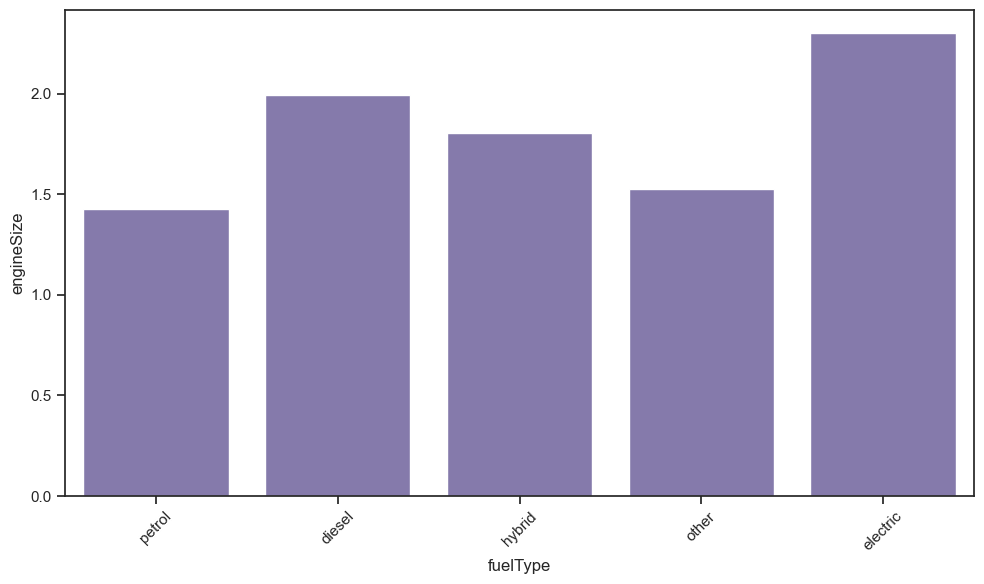

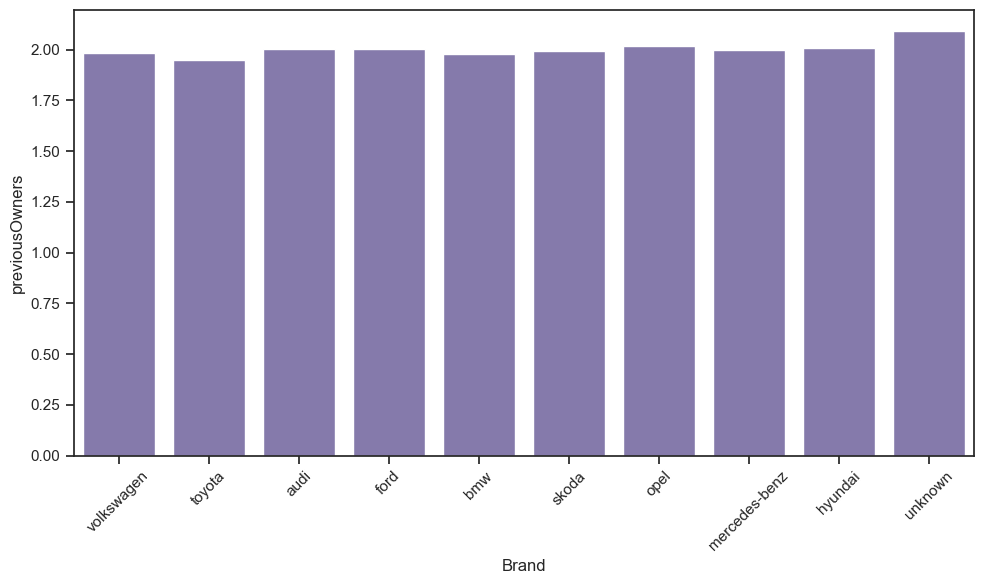

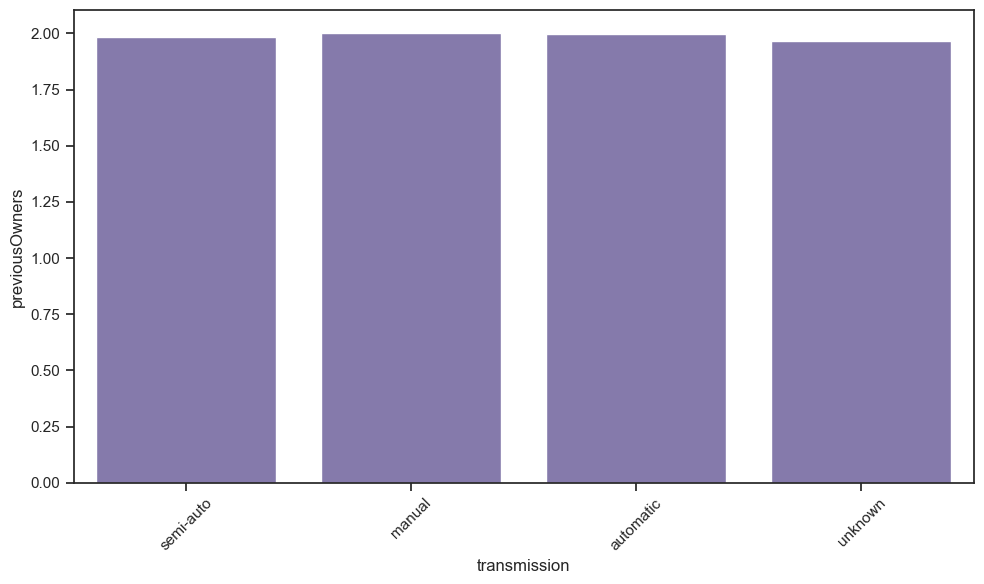

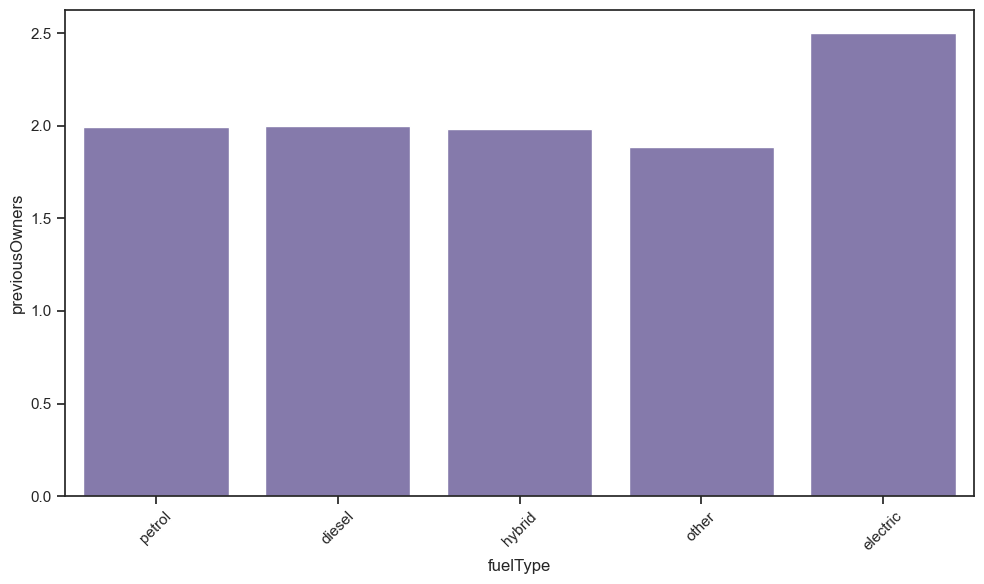

In [29]:
for column in metric_features:
    for x in [f for f in non_metric_features if f != 'model']:
        comparative_barplot(train, x, column)

Let's analyze only the most relevent relationships:<br>

`price` - `Brand`

- Most of the prices stay in between 0 - 40,000 for each Brand.
- audi, bmw and mercede-benz have, in average, pricier cars (mean around 23,000£) volkwagen comes next(~17,000£) and the rest stays around 11,000£. Unknown around 18,000£ 

`price` - `transmission`

- semi-auto and automatic are, in average, pricier (~24,000£ and ~22,000£) than manual (13,000£) and 'unknown' (~16,000£)

`price` - `fuelType`

- diesel and hybrid are, in average, pricier than others but its a slight diference
- petrol has some outliers with very high price

`mileage` - `transmission`

- mileage counts are, in average, lower on semi-auto cars(~17,000) than in manual (~25,000) and automatic (~24,000) 

`mileage` - `fuelType`

- diesel cars have, in average, higher mileage counts(~28,000). hybrid, 'others' and electric come after (~24,000), and then comes petrol(~18,000)

`tax` - `Brand`

- Toyta cars have, in average, cheaper tax (~90£) than other brands (~120£)

`tax` - `transmission`

- manual transmission cars have, in average, cheaper tax (~110£) than semi-auto and automatic cars (both ~130£)

`tax` - `fuelType`

- hybrid and electric cars have, in average, cheaper tax (~70£ and 0£, respectively) than petrol(~125£), diesel(~110£) and 'other'(~110£) cars

`mpg` - `Brand`

- Toyta cars have, in average, higher mpg (~63) than other brands (~55). Toyota models are, in average, more efficient

`mpg` - `fuelType`

- hybrid (~80), 'other'(~80) and electric(~200) are, in average, more eficcient
- There are values in hybrid, 'other' and electric around 450, probably errors due to miles per GALON inconsistencies with cars that are not petrol or diesel.

`engineSize` - `Brand`

- engineSize is, in average, higher for the (in average) pricier brands, audi, bmw and mercedes-benz (~2L) — other brands ~1.5L

`engineSize` - `transmission`

- engineSize is, in average, lower for manual cars (~1.4L) than for semi-auto and automatic cars (~2L)

`engineSize` - `fuelType`

- engineSize is, in average, lower for petrol and 'other' cars (~1.4L) than for diesel and hybrid cars (~1.7L)

***

#### 2.2.2.3 Categorical - Categorical

In this section we analyze categorical-categorical relationships with heatmaps and bar plots

`Brand` - `transmission`

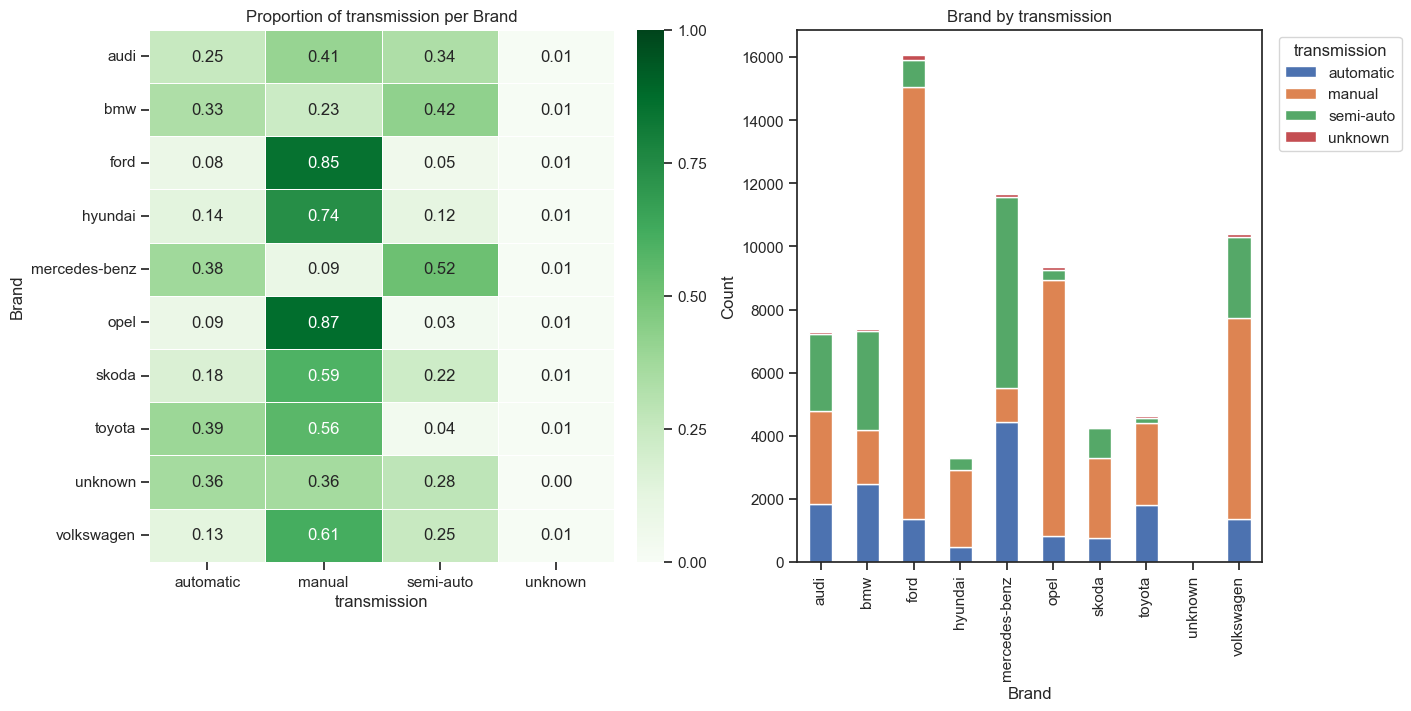

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14,7), constrained_layout=True)

# --- Heatmap  ---
ct_prop = pd.crosstab(train['Brand'], train['transmission'], normalize='index')
sns.heatmap(ct_prop, annot=True, fmt=".2f", cmap="Greens", linewidths=0.5, ax=axes[0], vmin=0, vmax=1,               
    cbar_kws={"ticks":[0, .25, .5, .75, 1]}
)
axes[0].set_title("Proportion of transmission per Brand")
axes[0].set_xlabel("transmission")
axes[0].set_ylabel("Brand")

# --- Bar plot ---
ct_cnt = pd.crosstab(train['Brand'], train['transmission'])
ct_cnt.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Brand by transmission')
axes[1].set_xlabel("Brand")
axes[1].set_ylabel("Count")
axes[1].legend(title="transmission", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()

- The pricier Brands (audi, bmw and mercedes-benz), seen in last section, are the brands with more proportion of semi-auto cars. Wich was expected because semi-auto cars are also pricier.
- Most of the Brands have manual cars as their main type of transmission.

`Brand` - `fuelType`

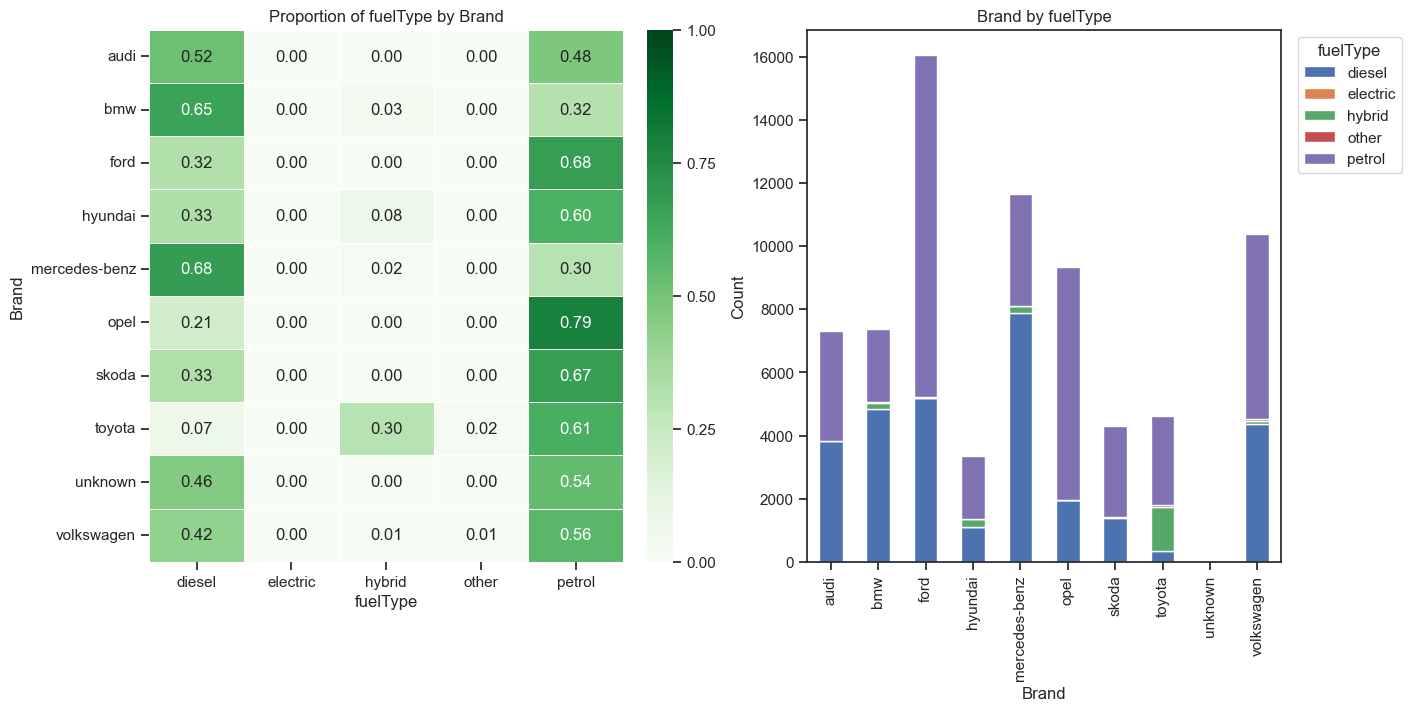

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14,7), constrained_layout=True)

# --- Heatmap  ---
ct_prop = pd.crosstab(train['Brand'], train['fuelType'], normalize='index')
sns.heatmap(ct_prop, annot=True, fmt=".2f", cmap="Greens", linewidths=0.5, ax=axes[0], vmin=0, vmax=1,          
    cbar_kws={"ticks":[0, .25, .5, .75, 1]}
)
axes[0].set_title("Proportion of fuelType by Brand")
axes[0].set_xlabel("fuelType")
axes[0].set_ylabel("Brand")

# --- Bar plot ---
ct_cnt = pd.crosstab(train['Brand'], train['fuelType'])
ct_cnt.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Brand by fuelType')
axes[1].set_xlabel("Brand")
axes[1].set_ylabel("Count")
axes[1].legend(title="fuelType", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()

- *diesel* and *petrol* cars are the most common between Brands, with hybrid having some relevancy in some of them.
- *electric* and *other* seem almost irrelevent so we will check the model-fuelType relationship to see if these classes make sense.

`fuelType` - `transmission`

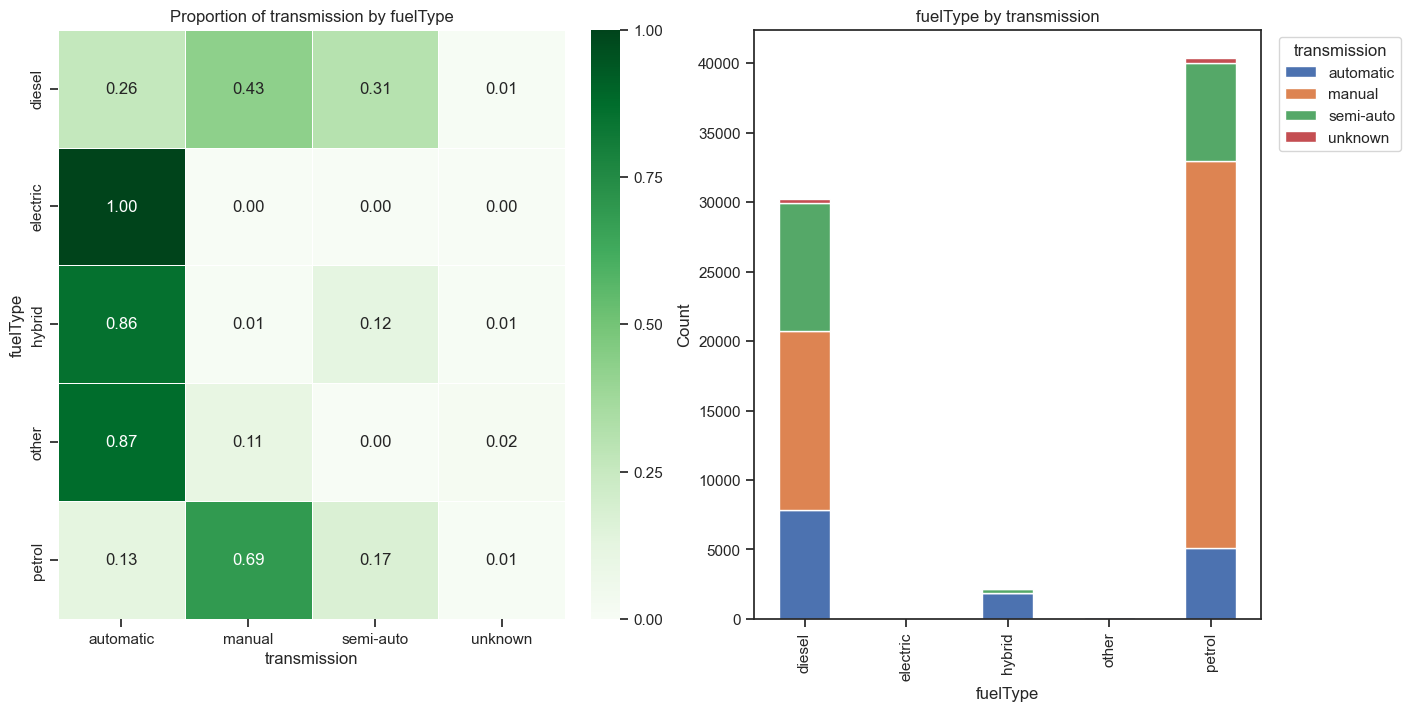

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14,7), constrained_layout=True)

# --- Heatmap  ---
ct_prop = pd.crosstab(train['fuelType'], train['transmission'], normalize='index')
sns.heatmap(ct_prop, annot=True, fmt=".2f", cmap="Greens", linewidths=0.5, ax=axes[0], vmin=0, vmax=1,          
    cbar_kws={"ticks":[0, .25, .5, .75, 1]}
)
axes[0].set_title("Proportion of transmission by fuelType")
axes[0].set_xlabel("transmission")
axes[0].set_ylabel("fuelType")

# --- Bar plot ---
ct_cnt = pd.crosstab(train['fuelType'], train['transmission'])
ct_cnt.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('fuelType by transmission')
axes[1].set_xlabel("fuelType")
axes[1].set_ylabel("Count")
axes[1].legend(title="transmission", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()

- *petrol* cars are mostly manual.
- *diesel* cars are spread between the different transmission types, with manual being the most relevant.
- *hybrid*, *electric* and *other* cars are mostly automatic.

`fuelType` - `model`

WARNING!!<br>
This next representation is a little hard to look at (because of the wide number of different models) but it helped us a lot in discriminating if *electric* and *other* fuelType categories make sense in this dataset.

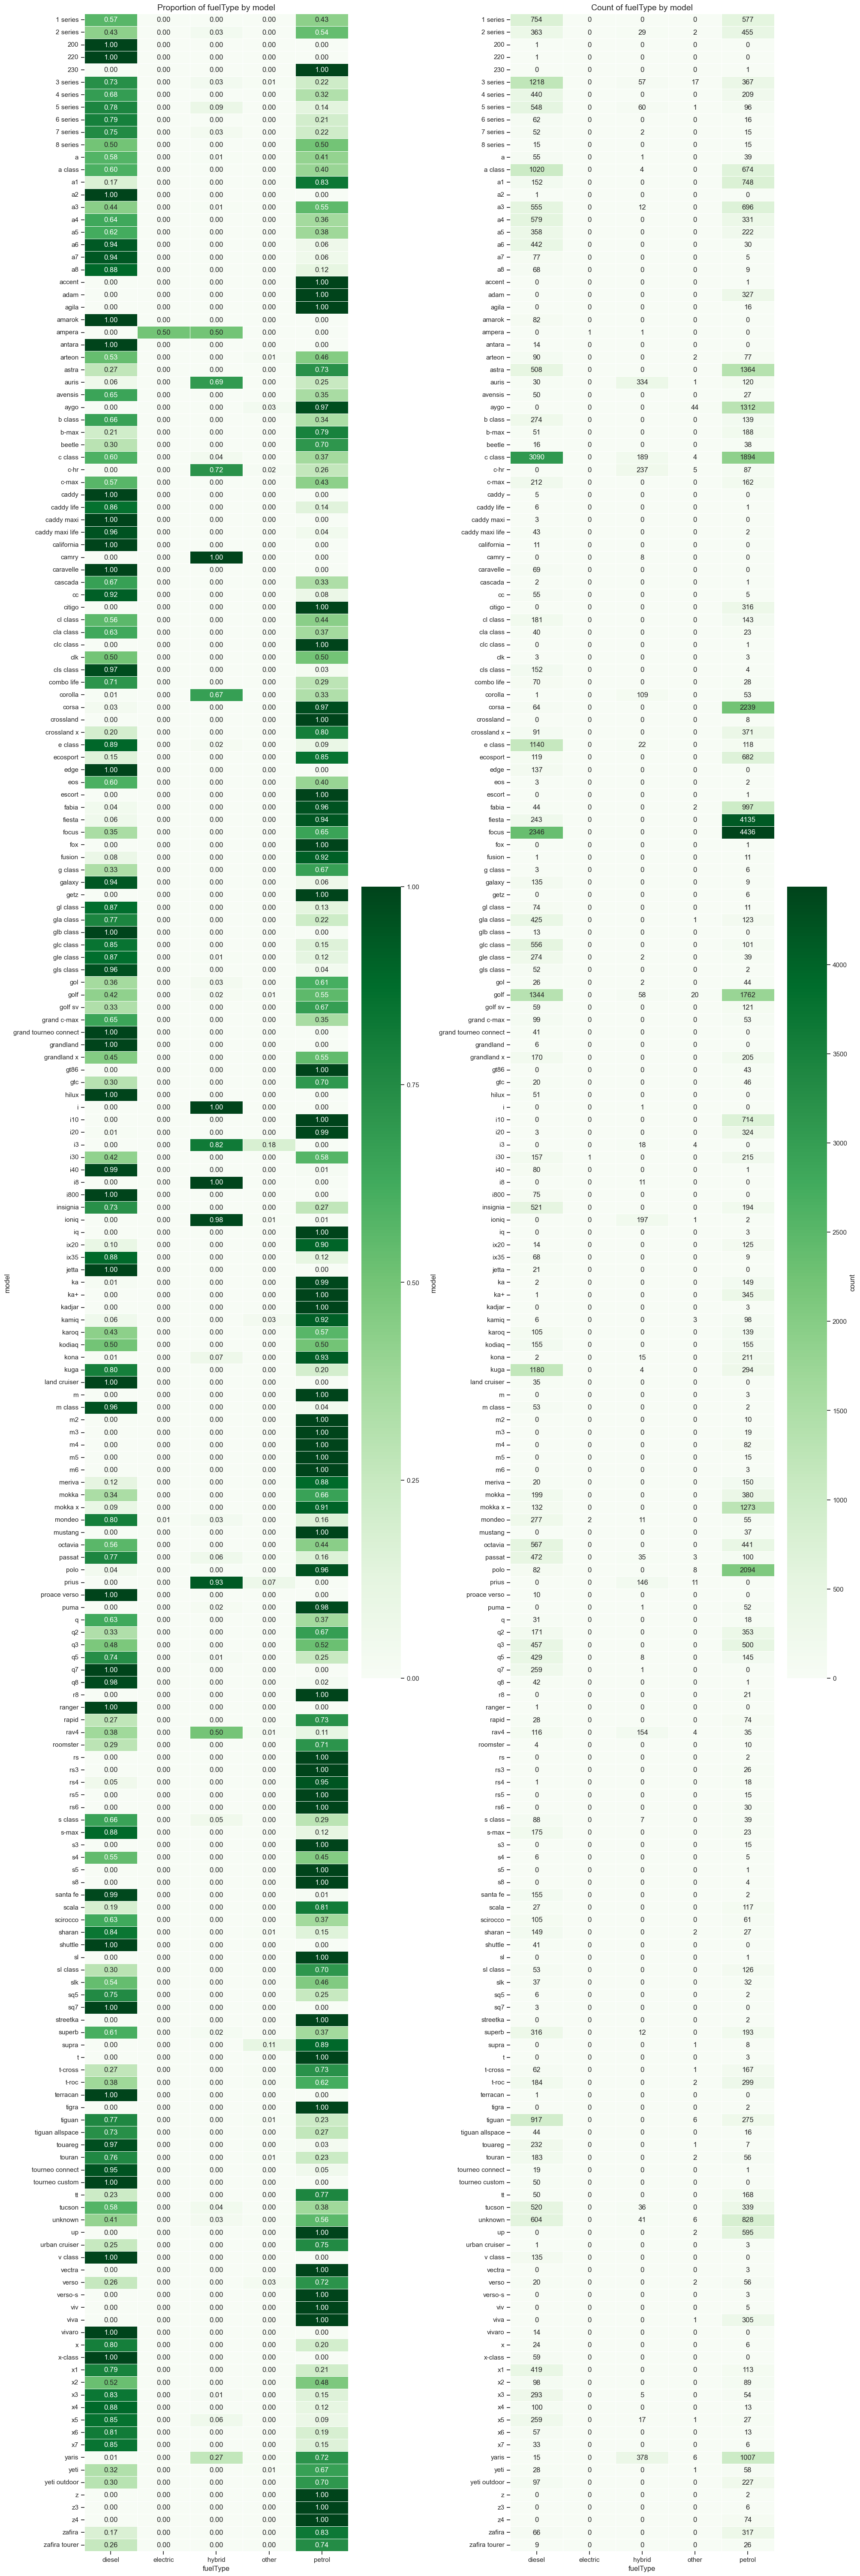

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(20, 60), constrained_layout=True)

# --- Heatmap (PROPORTION) ---
ct_prop = pd.crosstab(train['model'], train['fuelType'], normalize='index')
sns.heatmap(
    ct_prop,
    annot=True, fmt=".2f",
    cmap="Greens",
    linewidths=0.5,
    vmin=0, vmax=1,
    cbar_kws={"ticks": [0, .25, .5, .75, 1]},
    ax=axes[0]
)
axes[0].set_title("Proportion of fuelType by model", fontsize=14)
axes[0].set_xlabel("fuelType", fontsize=12)
axes[0].set_ylabel("model", fontsize=12)

# --- Heatmap (COUNTS) ---
ct_cnt = pd.crosstab(train['model'], train['fuelType'])
sns.heatmap(
    ct_cnt,
    annot=True, fmt="d",
    cmap="Greens",
    linewidths=0.5,
    cbar_kws={"label": "count"},
    ax=axes[1]
)
axes[1].set_title("Count of fuelType by model", fontsize=14)
axes[1].set_xlabel("fuelType", fontsize=12)
axes[1].set_ylabel("model", fontsize=12)

plt.show()

`electric`

- Here we can see that only *mondeo*, *i30* and *ampera* models have observations labled as *electric*.
- *mondeo* and *i30* are *diesel/petrol* cars (because of the large number of observations in those categories, ~60-300 observation) with *modeo* having some hybrid(16). Here we suspect that *electric* lable is an error.
- *ampera* has only two observations, one *hybrid* and the other *electric*.

In [34]:
train[train['model'] == 'ampera']

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
31953,63830,opel,ampera,2014.0,11400,automatic,64764.0,hybrid,0.0,235.4,NaN,92.0,0.0,0.0
37023,64169,opel,ampera,2015.0,12999,automatic,34461.0,electric,0.0,235.4,1.4,83.0,1.0,0.0


- After doing some research, opel ampera from 2014-2015 is an *hybrid* car, not *electric*.<br> From "Vauxhall Ampera (2012-2015) review" (https://www.autoexpress.co.uk/vauxhall/ampera) "the Ampera is powered by a 85bhp 1.4-litre petrol engine and a 148bhp electric motor."

`other`

- We can see that the *other* category has some values across some models but it always looks like they are errors.
- Most of the *other* values appear when there are *hybrid* cars, this can mean that the user's mistakenly choose *other*.
- When *other* values appear and there are no *hybrid* cars (which is rare), the proportion of *other* is very low (<=3%) (only *supra* model has 11% but the count is 8 *petrol* to 1 *other*).

We then assume that *electric* and *other* categories are just mistakes -> We will re-assign those observations to diesel, hybrid or petrol categories in the next section.

***

# 3. Data cleaning and Preprocessing

From missing values, duplicates and type fixes to feature creation and encodings used downstream.

***

## 3.1 Missing Values

**Fix Brand missing values**

We use `train_brand_imputer` and `impute_unknown_brand` (From Inconsistencies_vocab_func.py) to fill the 'Brand' missing values. We train the imputer on the train set and then apply to both.

In [35]:
imputer = train_brand_imputer(train, feature_cols, cat_features, num_features)

train = impute_unknown_brand(train, imputer, feature_cols)

test = impute_unknown_brand(test, imputer, feature_cols)


**Fix model missing values**

Then we do the same for 'model' with `train_model_imputer` and `impute_unknown_model`.

In [36]:
imputer = train_model_imputer(train, feature_cols, cat_features, num_features)

train = impute_unknown_model(train, imputer, feature_cols)

test = impute_unknown_model(test, imputer, feature_cols)


**Fix transmission missing values**

In [37]:
train['transmission'].unique()

array(['semi-auto', 'manual', 'automatic', nan, 'unknown'], dtype=object)

We will re-assign nan and unknown values to the mode per model

In [38]:
def transmission_unknown_nan_fix(df, ref, unknown="unknown"):
    """
    Replace `transmission` values that are NaN or `unknown` using modes learned from `ref` (train).

    - First, fill using the most common transmission for the same `model` (excluding NaN/unknown).
    - If still missing, fill with the global most common transmission (excluding NaN/unknown).

    Use: train = transmission_unknown_nan_fix(train, train); test = transmission_unknown_nan_fix(test, train)
    """

    # learn mapping ONLY from ref (train)  -> no leakage
    valid = ref["transmission"].notna() & (ref["transmission"] != unknown)
    mode_by_model = ref.loc[valid].groupby("model")["transmission"].agg(
        lambda s: s.mode().iat[0] if not s.mode().empty else np.nan
    )
    global_mode = ref.loc[valid, "transmission"].mode().iat[0]

    # apply to df (train or test)
    mask = df["transmission"].isna() | (df["transmission"] == unknown)
    df.loc[mask, "transmission"] = df.loc[mask, "model"].map(mode_by_model)
    df["transmission"] = df["transmission"].fillna(global_mode).replace(unknown, global_mode)
    return df

In [39]:
train = transmission_unknown_nan_fix(train, ref=train)
test  = transmission_unknown_nan_fix(test,  ref=train)

**Fix fuelType missing values**

We saw that *electric* and *other* are, most probably, errors. We will set those to "NaN"

In [40]:
#set fuelType 'electric' and 'other' to Nan
train.loc[train['fuelType'].isin(['electric', 'other']), 'fuelType'] = np.nan

We will re-assign nan values to the mode per model.<br>
'other' values to hybrid if there is at least 1 hybrid car for the same car model (we assume that 'other' values are supposed to be hybrid in those cases)<br>
If there are no hybrid cars for that model, 'other' values fall to the per model mode.

In [41]:
def fuelType_nan_fix(df, ref):
    """
    Rules:
      A) If a model has at least one 'hybrid' entry (in ref_df), then set all 'other' for that model to 'hybrid'.
      B) If a model has no 'hybrid', then set 'other' to the model mode (excluding NaN and excluding 'other').
      C) Fill fuelType NaN with the model mode (excluding NaN and excluding 'other'); fallback to global mode
         (excluding NaN and excluding 'other').

    ref_df: dataframe used to "learn" the per-model and global modes (defaults to input_df).
    """
    # learn ONLY from ref (train) -> no leakage
    hybrid_models = set(ref.loc[ref["fuelType"] == 'hybrid', "model"])

    mode_by_model = (
        ref.loc[ref["fuelType"].notna() & (ref["fuelType"] != 'other')]
           .groupby("model")["fuelType"]
           .agg(lambda s: s.mode().iat[0] if not s.mode().empty else np.nan)
    )
    global_mode = ref.loc[ref["fuelType"].notna() & (ref["fuelType"] != 'other'), "fuelType"].mode().iat[0]
    # A) if model has any hybrid in ref -> other -> hybrid
    m_other = (df["fuelType"] == 'other') & df["model"].isin(hybrid_models)
    df.loc[m_other, "fuelType"] = 'hybrid'

    # B) remaining other -> per-model mode (excluding other)
    m_other = (df["fuelType"] == 'other')
    df.loc[m_other, "fuelType"] = df.loc[m_other, "model"].map(mode_by_model)

    # C) NaN -> per-model mode; fallback -> global
    m_nan = df["fuelType"].isna()
    df.loc[m_nan, "fuelType"] = df.loc[m_nan, "model"].map(mode_by_model)
    df["fuelType"] = df["fuelType"].fillna(global_mode)

    return df


In [42]:
train = fuelType_nan_fix(train, ref=train)

test = fuelType_nan_fix(test, ref=train)

***

## 3.2 Duplicates

Count and drop duplicate rows from train.

In [43]:
train.duplicated().sum()

np.int64(0)

In [44]:
train[train.duplicated(keep=False)]

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage


There are no duplicated rows in the train dataset

***

## 3.3 Feature Engeneering

Create derived features and harmonize types.

***

### 3.2.1 Feature Creation

We will create a carAge feature which is calculated by the reference year '2020' minus the 'year' of each observation.<br>
Then replace 'year' with 'carAge' (redundant information).

In [45]:
train['carAge'] = 2020 - train['year']

test['carAge'] = 2020 - test['year']

metric_features.append('carAge')
metric_features

['price',
 'year',
 'mileage',
 'tax',
 'mpg',
 'engineSize',
 'previousOwners',
 'carAge']

Check if there are no negative carAge values

In [46]:
print(f'The number of rows with negative carAge values is: {train.loc[train['carAge'] < (0), ['carAge']].size}')
print(f'The number of rows with non-integer carAge values are: {train.loc[(train['carAge'] != round(train['carAge'])) & (train['carAge'].notna()), ['carAge']].size}')

The number of rows with negative carAge values is: 0
The number of rows with non-integer carAge values are: 0


Drop year

In [47]:
train.drop(columns=['year'], inplace=True)

test.drop(columns=['year'], inplace=True)

metric_features.remove('year')
train.sample(10)

,carID,Brand,model,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage,carAge
65499,23946,ford,ka,7600,manual,11447.0,petrol,145.0,57.7,NaN,68.0,1.0,0.0,2.0
54400,28239,ford,kuga,23890,semi-auto,8123.0,diesel,NaN,38.7,2.0,40.0,4.0,0.0,1.0
4351,45877,mercedes-benz,c class,14750,automatic,28612.0,diesel,20.0,65.7,2.1,63.0,3.0,0.0,4.0
25753,27282,ford,fiesta,12990,manual,2555.0,petrol,145.0,48.7,1.1,66.0,2.0,0.0,1.0
30149,69319,volkswagen,polo,8799,manual,27532.0,petrol,20.0,60.1,1.2,45.0,0.0,0.0,4.0
45431,53195,toyota,c-hr,30990,automatic,2500.0,hybrid,140.0,54.3,2.0,76.0,4.0,0.0,1.0
71751,55805,toyota,corolla,27495,automatic,998.0,hybrid,135.0,53.3,2.0,50.0,NaN,0.0,0.0
55791,31325,ford,fiesta,11450,manual,14377.0,petrol,145.0,56.5,1.0,85.0,2.0,0.0,2.0
15670,19912,ford,focus,11498,manual,22876.0,diesel,NaN,NaN,1.5,96.0,1.0,0.0,3.0
10467,46158,mercedes-benz,a class,11479,manual,84521.0,diesel,30.0,62.8,2.1,42.0,4.0,0.0,5.0


***

### 3.2.2 Data Type Conversions

Decide which numeric columns should be integers vs floats and convert accordingly.

In [48]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           75973 non-null  string 
 2   model           75973 non-null  string 
 3   price           75973 non-null  int64  
 4   transmission    75973 non-null  object 
 5   mileage         74141 non-null  float64
 6   fuelType        75973 non-null  object 
 7   tax             67691 non-null  float64
 8   mpg             68011 non-null  float64
 9   engineSize      73888 non-null  float64
 10  paintQuality%   73723 non-null  float64
 11  previousOwners  73689 non-null  float64
 12  hasDamage       74425 non-null  float64
 13  carAge          74124 non-null  float64
dtypes: float64(8), int64(2), object(2), string(2)
memory usage: 8.1+ MB


In [49]:
# Loop through each column in the DataFrame
for column in metric_features:

    print (f'{column}')
    print (f"Number of values with decimal cases: {((train[column].notna()) & (train[column] % 1 != 0)).sum()}")
    print("---"*8)

price
Number of values with decimal cases: 0
------------------------
mileage
Number of values with decimal cases: 386
------------------------
tax
Number of values with decimal cases: 0
------------------------
mpg
Number of values with decimal cases: 66370
------------------------
engineSize
Number of values with decimal cases: 35976
------------------------
previousOwners
Number of values with decimal cases: 0
------------------------
carAge
Number of values with decimal cases: 0
------------------------


`mileage` - Since the majority of the values aren't floats, we will convert mileage to integer <br>

`tax` - Since all of the values have decimal cases, we will convert tax to integer <br>

`mpg` - We should leave it as a float <br>

`engineSize` - We should leave it as a float <br>

`paintQuality%` - Since there are no paintQuality% values whith decimal places, let's convert it into integer <br>

`previousOwners` - Since there are no previousOwners values whith decimal places, let's convert it into integer <br>

`carAge` - Since there are no carAge values whith decimal places, let's convert it into integer <br>


In [50]:
def data_type_convert(input_df):

    #Data type conversions
    #mileage
    input_df['mileage'] = input_df['mileage'].round().astype('Int64')
    #tax
    input_df['tax'] = input_df['tax'].round().astype('Int64')
    #paintQuality%
    input_df['paintQuality%'] = input_df['paintQuality%'].round().astype('Int64')
    #previousOwners
    input_df['previousOwners'] = input_df['previousOwners'].round().astype('Int64')
    #carAge
    input_df['carAge'] = input_df['carAge'].round().astype('Int64')

    return input_df

In [51]:
train = data_type_convert(train)

test = data_type_convert(test)

In [52]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           75973 non-null  string 
 2   model           75973 non-null  string 
 3   price           75973 non-null  int64  
 4   transmission    75973 non-null  object 
 5   mileage         74141 non-null  Int64  
 6   fuelType        75973 non-null  object 
 7   tax             67691 non-null  Int64  
 8   mpg             68011 non-null  float64
 9   engineSize      73888 non-null  float64
 10  paintQuality%   73723 non-null  Int64  
 11  previousOwners  73689 non-null  Int64  
 12  hasDamage       74425 non-null  float64
 13  carAge          74124 non-null  Int64  
dtypes: Int64(5), float64(3), int64(2), object(2), string(2)
memory usage: 8.5+ MB


Now everything is in the right Dtype

***

### 3.2.3 Encoding before Train-Test Split

OHE is deterministic (no target leakage), so we can encode before splitting.

In [53]:
non_metric_features

['Brand', 'model', 'transmission', 'fuelType']

In [54]:
train['model'].nunique()

203

We will only use OHE for Brand, transmission and fueltype. Since model has a lot more unique values, we will use

In [55]:
categorical_cols = non_metric_features.copy()

categorical_cols.remove('model')

categorical_cols

['Brand', 'transmission', 'fuelType']

In [56]:
metric_features = ['price','mileage', 'tax', 'mpg', 'engineSize', 'previousOwners', 'carAge', 'paintQuality%']  # added paintQuality% again

This function will make the OHE encoding changes

In [57]:
def OneHotEncoder_catcols(input_df, ohe=None):
    """
    if ohe is None: do fit_transform and return also the trained encoder.
    If ohe is not None: use only transform with that encoder.
    """

    # if there is no encoder, create a new one (case of TRAIN)
    created_ohe = ohe is None
    if created_ohe:
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded_array = ohe.fit_transform(input_df[categorical_cols])
    else:
        # case of VAL / TEST: only transform
        encoded_array = ohe.transform(input_df[categorical_cols])

    encoded_cols = ohe.get_feature_names_out(categorical_cols)
    encoded_df   = pd.DataFrame(encoded_array,
                                columns=encoded_cols,
                                index=input_df.index)

    # choose metrics if the column 'price' exists (or not)
    has_price = 'price' in input_df.columns
    metrics   = metric_features if has_price else [c for c in metric_features if c != 'price']

    parts = [input_df[metrics], encoded_df]

    # optionally keep 'model' and 'hasDamage' if they exist
    for extra in ['model', 'hasDamage']:
        if extra in input_df.columns:
            parts.append(input_df[[extra]])

    input_df_encoded = pd.concat(parts, axis=1)

    # always return the encoded df and the encoder used
    return input_df_encoded, ohe


In [58]:
# TRAIN
train_OHE, ohe = OneHotEncoder_catcols(train)

# TEST
test_OHE, _ = OneHotEncoder_catcols(test, ohe=ohe)

In [59]:
test_OHE['carID'] = test['carID'].values

train_OHE['carID'] = train['carID'].values

Here we can see the columns that were created

In [60]:
train_OHE.columns

Index(['price', 'mileage', 'tax', 'mpg', 'engineSize', 'previousOwners',
       'carAge', 'paintQuality%', 'Brand_audi', 'Brand_bmw', 'Brand_ford',
       'Brand_hyundai', 'Brand_mercedes-benz', 'Brand_opel', 'Brand_skoda',
       'Brand_toyota', 'Brand_volkswagen', 'transmission_automatic',
       'transmission_manual', 'transmission_semi-auto', 'fuelType_diesel',
       'fuelType_hybrid', 'fuelType_petrol', 'model', 'hasDamage', 'carID'],
      dtype='object')

# 4. Export

Save tables for use in next notebooks.

In [61]:
train_OHE.to_csv('../project_data/train_data_EDA.csv')
test_OHE.to_csv('../project_data/test_data_EDA.csv')